# Assignment 1 — Exploratory Data Analysis (EDA)
## From Data to Understanding

**Course:** Introduction to Data Science  
**Student Name:** ISRAEL SAREL COHEN  
**Student ID:** 212941918  
**Dataset:** Hotel Booking Demand  

This notebook performs an end-to-end exploratory data analysis of hotel booking records. The analysis follows the assignment requirements: dataset selection, meta-analysis, data quality, univariate analysis, relationships and correlations, visualizations, index analysis, insights, and bonus analyses.

All explanations, comments, titles, and documentation are written in English as required.

## 1. Setup and Data Loading

The notebook expects `hotel_booking_demand.csv` to be located in the same folder as the notebook. A public TidyTuesday URL is included only as a fallback for reproducibility.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_FILE = Path("hotel_booking_demand.csv")
DATA_URL = (
    "https://raw.githubusercontent.com/rfordatascience/"
    "tidytuesday/master/data/2020/2020-02-11/hotels.csv"
)

if DATA_FILE.exists():
    hotel_data = pd.read_csv(DATA_FILE)
    data_location = str(DATA_FILE)
else:
    hotel_data = pd.read_csv(DATA_URL)
    data_location = DATA_URL

print("Dataset loaded successfully.")
print(f"Data source used: {data_location}")
print(f"Rows: {hotel_data.shape[0]:,}")
print(f"Columns: {hotel_data.shape[1]}")

display(hotel_data.head())

Dataset loaded successfully.
Data source used: hotel_booking_demand.csv
Rows: 119,390
Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# 2. Dataset Selection

## 2.1 Dataset Requirements

The assignment requires tabular data with at least 1,000 rows, at least 10 columns, and a combination of numerical, categorical, and time-related variables.

In [2]:
minimum_rows = 1000
minimum_columns = 10

numeric_columns_detected = hotel_data.select_dtypes(include=np.number).columns.tolist()
categorical_columns_detected = hotel_data.select_dtypes(include=["object", "category"]).columns.tolist()
time_related_columns = [
    column
    for column in hotel_data.columns
    if "date" in column.lower() or "year" in column.lower() or "month" in column.lower()
]

requirements_summary = pd.DataFrame({
    "Requirement": [
        "At least 1,000 rows",
        "At least 10 columns",
        "Contains numerical variables",
        "Contains categorical variables",
        "Contains time-related variables",
    ],
    "Satisfied": [
        hotel_data.shape[0] >= minimum_rows,
        hotel_data.shape[1] >= minimum_columns,
        len(numeric_columns_detected) > 0,
        len(categorical_columns_detected) > 0,
        len(time_related_columns) > 0,
    ],
    "Details": [
        f"{hotel_data.shape[0]:,} rows",
        f"{hotel_data.shape[1]} columns",
        f"{len(numeric_columns_detected)} numeric dtype columns",
        f"{len(categorical_columns_detected)} object/category dtype columns",
        ", ".join(time_related_columns),
    ],
})

display(requirements_summary)

,Requirement,Satisfied,Details
0,"At least 1,000 rows",True,"119,390 rows"
1,At least 10 columns,True,32 columns
2,Contains numerical variables,True,20 numeric dtype columns
3,Contains categorical variables,True,12 object/category dtype columns
4,Contains time-related variables,True,"arrival_date_year, arrival_date_month, arrival..."


## 2.2 Data Source Description

**Original source:** António, N., de Almeida, A., & Nunes, L. (2019), *Hotel booking demand datasets*, Data in Brief, 22, 41–49. DOI: 10.1016/j.dib.2018.11.126.

**Working copy:** The CSV used here is the combined version distributed through the TidyTuesday project (2020-02-11). The original study contains two hotel datasets; the combined file adds a `hotel` column identifying City Hotel or Resort Hotel.

**Purpose of collection:** The records originated from hotel Property Management Systems (PMS). They represent real operational reservations and were later prepared for research and educational uses such as demand analysis, revenue management, data mining, and machine learning.

**Collector / preparing authors:** The published dataset was prepared and documented by Nuno António, Ana de Almeida, and Luís Nunes from operational hotel records.

**Domain context:** Each row represents a hotel booking record. The data contains both canceled and non-canceled bookings and covers arrival dates from July 2015 through August 2017. Variables describe booking timing, stay duration, guests, booking channels, room information, price, customer type, deposit type, and reservation status.

**Sources:**  
- https://doi.org/10.1016/j.dib.2018.11.126  
- https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-02-11

# 3. Meta-Analysis of the Data

## 3.1 File Analysis

In [3]:
if DATA_FILE.exists():
    file_size_bytes = DATA_FILE.stat().st_size
    file_size_mb = file_size_bytes / (1024 ** 2)
    file_name = DATA_FILE.name
    file_format = DATA_FILE.suffix.replace(".", "").upper()
else:
    file_size_mb = np.nan
    file_name = "Remote CSV"
    file_format = "CSV"

file_analysis = pd.DataFrame({
    "Property": [
        "File name",
        "File size",
        "File format",
        "Original file creation date",
        "Published dataset period",
        "Data purpose",
    ],
    "Value": [
        file_name,
        f"{file_size_mb:.2f} MB" if pd.notna(file_size_mb) else "Not available for remote source",
        file_format,
        "Not provided by the source",
        "Arrival dates from July 2015 to August 2017",
        "Operational hotel booking analysis and research",
    ],
})

display(file_analysis)

print(
    "Note: the local file system modification timestamp is not treated as the "
    "original creation date because it reflects the downloaded/uploaded copy, "
    "not the source dataset creation time."
)

,Property,Value
0,File name,hotel_booking_demand.csv
1,File size,16.07 MB
2,File format,CSV
3,Original file creation date,Not provided by the source
4,Published dataset period,Arrival dates from July 2015 to August 2017
5,Data purpose,Operational hotel booking analysis and research


Note: the local file system modification timestamp is not treated as the original creation date because it reflects the downloaded/uploaded copy, not the source dataset creation time.


## 3.2 Data Structure

This step documents the dataset as originally loaded, before changing data types or cleaning values.

In [4]:
structure_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Numeric dtype columns",
        "Object/category dtype columns",
    ],
    "Value": [
        hotel_data.shape[0],
        hotel_data.shape[1],
        hotel_data.select_dtypes(include=np.number).shape[1],
        hotel_data.select_dtypes(include=["object", "category"]).shape[1],
    ],
})

column_structure = pd.DataFrame({
    "Column": hotel_data.columns,
    "Data Type": hotel_data.dtypes.astype(str).values,
    "Missing Values": hotel_data.isna().sum().values,
    "Unique Values": [hotel_data[column].nunique(dropna=False) for column in hotel_data.columns],
})

display(structure_summary)
display(column_structure)

,Metric,Value
0,Number of rows,119390
1,Number of columns,32
2,Numeric dtype columns,20
3,Object/category dtype columns,12


,Column,Data Type,Missing Values,Unique Values
0,hotel,object,0,2
1,is_canceled,int64,0,2
2,lead_time,int64,0,479
3,arrival_date_year,int64,0,3
4,arrival_date_month,object,0,12
5,arrival_date_week_number,int64,0,53
6,arrival_date_day_of_month,int64,0,31
7,stays_in_weekend_nights,int64,0,17
8,stays_in_week_nights,int64,0,35
9,adults,int64,0,14


### Initial Structural Observations

- Column names are descriptive and consistently use `snake_case`.
- The dataset combines numerical, categorical, identifier, binary, and date-related fields.
- Some integer columns are semantic categories rather than continuous measurements. For example, `is_canceled` and `is_repeated_guest` are binary variables.
- `agent` and `company` are numeric identifiers; arithmetic operations on the ID values are not meaningful.
- `reservation_status_date` is loaded as an object and should be converted to a datetime before time-based analysis.
- The arrival date is split into year, month, and day columns rather than stored as one complete date.

### Collection Context and Potential Bias

The data originated from **operational hotel systems**, not from a controlled experiment. It was later curated for research. This distinction matters because operational data reflects real business processes but can also contain process-specific missingness, recording conventions, and selection bias.

Potential limitations include:

- **Selection bias:** only two hotels in Portugal are represented.
- **Time-period bias:** the records cover a limited historical window (2015–2017).
- **Operational recording bias:** the variables reflect what the hotels' systems recorded, not every factor that may influence customer behavior.
- **Missing-data bias:** missing values may be related to booking channels or business processes rather than being completely random.
- **Generalization risk:** findings should not automatically be generalized to all hotels, countries, or later time periods.

### Date Preparation for Later Analysis

The original structure above is preserved in `hotel_data`. A separate `analysis_data` copy is used for parsed dates and later analysis.

In [5]:
analysis_data = hotel_data.copy()

analysis_data["reservation_status_date"] = pd.to_datetime(
    analysis_data["reservation_status_date"],
    errors="coerce"
)

analysis_data["arrival_date"] = pd.to_datetime(
    analysis_data["arrival_date_year"].astype(str)
    + "-"
    + analysis_data["arrival_date_month"]
    + "-"
    + analysis_data["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
    errors="coerce"
)

print(f"Invalid parsed arrival dates: {analysis_data['arrival_date'].isna().sum()}")
print(f"Invalid parsed reservation status dates: {analysis_data['reservation_status_date'].isna().sum()}")

Invalid parsed arrival dates: 0
Invalid parsed reservation status dates: 0


# 4. Data Quality and Completeness

## 4.1 Missing Data

### Extent of Missingness

In [6]:
missing_summary = pd.DataFrame({
    "Missing Values": hotel_data.isna().sum(),
    "Missing Percentage (%)": (hotel_data.isna().mean() * 100).round(4),
})

missing_summary = (
    missing_summary[missing_summary["Missing Values"] > 0]
    .sort_values("Missing Percentage (%)", ascending=False)
)

display(missing_summary)

,Missing Values,Missing Percentage (%)
company,112593,94.3069
agent,16340,13.6862
country,488,0.4087
children,4,0.0034


### Missingness Pattern

To check whether missingness appears completely random, missing percentages are compared across hotel type, market segment, and distribution channel.

In [7]:
missing_columns = ["company", "agent", "country", "children"]

def missing_percentage_by_group(dataframe, group_column, columns):
    return (
        dataframe.groupby(group_column)[columns]
        .agg(lambda series: series.isna().mean() * 100)
        .round(2)
    )

missing_by_hotel = missing_percentage_by_group(hotel_data, "hotel", missing_columns)
missing_by_market_segment = missing_percentage_by_group(hotel_data, "market_segment", missing_columns)
missing_by_distribution_channel = missing_percentage_by_group(
    hotel_data,
    "distribution_channel",
    missing_columns,
)

print("Missing percentage by hotel:")
display(missing_by_hotel)

print("Missing percentage by market segment:")
display(missing_by_market_segment)

print("Missing percentage by distribution channel:")
display(missing_by_distribution_channel)

Missing percentage by hotel:


,company,agent,country,children
hotel,,,,
City Hotel,95.35,10.25,0.03,0.01
Resort Hotel,92.24,20.49,1.16,0.00


Missing percentage by market segment:


,company,agent,country,children
market_segment,,,,
Aviation,10.55,89.45,0.00,0.00
Complementary,57.87,86.14,1.21,0.00
Corporate,15.56,86.76,3.47,0.00
Direct,98.35,47.65,1.25,0.01
Groups,92.98,20.94,0.03,0.00
Offline TA/TO,99.56,1.61,0.24,0.00
Online TA,99.83,0.62,0.13,0.00
Undefined,100.00,100.00,0.00,100.00


Missing percentage by distribution channel:


,company,agent,country,children
distribution_channel,,,,
Corporate,23.87,83.02,2.79,0.0
Direct,94.51,52.07,1.11,0.0
GDS,99.48,1.04,0.00,0.0
TA/TO,99.07,3.24,0.14,0.0
Undefined,100.00,60.00,0.00,80.0


### Missing-Data Interpretation

- `company` is missing in most rows, and its missingness varies by booking context. Since it is an identifier, a missing value can plausibly mean that no company was associated with the reservation.
- `agent` also shows a structured pattern. Some channels naturally involve travel agents while others do not, so missingness may contain business meaning.
- `country` has a low missing rate but should not be silently imputed to the most frequent country because that would create false geographic information.
- `children` is missing in only four records; the amount is too small to infer a reliable missingness pattern.

Overall, missingness appears at least partly **process-related rather than completely random**, especially for `company` and `agent`.

In [8]:
children_median = hotel_data["children"].median()

missing_data_treatment = pd.DataFrame({
    "Column": ["company", "agent", "country", "children"],
    "Missing (%)": [
        hotel_data["company"].isna().mean() * 100,
        hotel_data["agent"].isna().mean() * 100,
        hotel_data["country"].isna().mean() * 100,
        hotel_data["children"].isna().mean() * 100,
    ],
    "Recommended Treatment": [
        "Preserve missingness or encode a separate missing indicator/category",
        "Preserve missingness or encode a separate missing indicator/category",
        "Encode as 'Unknown' when a complete categorical field is required",
        f"Impute with the median ({children_median:.0f}) if a complete numeric field is required",
    ],
    "Reason": [
        "Company is an identifier; mean/median imputation would create artificial IDs.",
        "Agent is an identifier; numeric imputation would create artificial IDs.",
        "Country has low missingness, but guessing a country would create false information.",
        "Only four values are missing; median is robust for this discrete count variable.",
    ],
})

missing_data_treatment["Missing (%)"] = missing_data_treatment["Missing (%)"].round(4)
display(missing_data_treatment)

,Column,Missing (%),Recommended Treatment,Reason
0,company,94.3069,Preserve missingness or encode a separate miss...,Company is an identifier; mean/median imputati...
1,agent,13.6862,Preserve missingness or encode a separate miss...,Agent is an identifier; numeric imputation wou...
2,country,0.4087,Encode as 'Unknown' when a complete categorica...,"Country has low missingness, but guessing a co..."
3,children,0.0034,Impute with the median (0) if a complete numer...,Only four values are missing; median is robust...


## 4.2 Duplicates

The dataset does not contain a unique booking identifier. Therefore, identical records cannot automatically be treated as erroneous duplicates. Both full duplicates and a heuristic form of partial duplicates are examined.

In [9]:
full_duplicate_count = int(hotel_data.duplicated(keep="first").sum())
full_duplicate_group_rows = int(hotel_data.duplicated(keep=False).sum())

partial_duplicate_key = [
    "hotel",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "agent",
    "company",
    "customer_type",
]

partial_duplicate_count = int(
    hotel_data.duplicated(subset=partial_duplicate_key, keep="first").sum()
)
partial_duplicate_group_rows = int(
    hotel_data.duplicated(subset=partial_duplicate_key, keep=False).sum()
)

duplicate_summary = pd.DataFrame({
    "Duplicate Type": ["Full duplicates", "Potential partial duplicates"],
    "Additional Duplicate-Looking Rows": [full_duplicate_count, partial_duplicate_count],
    "Rows Involved in Duplicate Groups": [full_duplicate_group_rows, partial_duplicate_group_rows],
    "Percentage of Dataset (%)": [
        round(full_duplicate_count / len(hotel_data) * 100, 2),
        round(partial_duplicate_count / len(hotel_data) * 100, 2),
    ],
})

display(duplicate_summary)

potential_partial_duplicates = (
    hotel_data.loc[
        hotel_data.duplicated(subset=partial_duplicate_key, keep=False),
        partial_duplicate_key + ["is_canceled", "lead_time", "adr", "reservation_status"],
    ]
    .sort_values(partial_duplicate_key)
)

display(potential_partial_duplicates.head(10))

,Duplicate Type,Additional Duplicate-Looking Rows,Rows Involved in Duplicate Groups,Percentage of Dataset (%)
0,Full duplicates,31994,40165,26.80
1,Potential partial duplicates,45362,59046,37.99


,hotel,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,market_segment,distribution_channel,reserved_room_type,agent,company,customer_type,is_canceled,lead_time,adr,reservation_status
40562,City Hotel,2015,August,1,2,1,1,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,0,117,72.50,Check-Out
40578,City Hotel,2015,August,1,2,1,1,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,0,117,72.50,Check-Out
40585,City Hotel,2015,August,1,2,1,1,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,0,117,72.50,Check-Out
40591,City Hotel,2015,August,1,2,1,1,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,0,4,36.25,Check-Out
40563,City Hotel,2015,August,1,2,1,2,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,1,117,94.50,Canceled
40564,City Hotel,2015,August,1,2,1,2,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,1,117,94.50,Canceled
40566,City Hotel,2015,August,1,2,1,2,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,0,117,94.50,Check-Out
40567,City Hotel,2015,August,1,2,1,2,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,0,117,94.50,Check-Out
40568,City Hotel,2015,August,1,2,1,2,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,1,117,94.50,Canceled
40569,City Hotel,2015,August,1,2,1,2,0.0,0,ITA,Offline TA/TO,TA/TO,A,17.0,NaN,Transient-Party,1,117,94.50,Canceled


### Duplicate Interpretation

- Full duplicate-looking rows exist, but there is no unique booking ID that proves they are accidental copies.
- Two real customers may have reservations with the same recorded attributes.
- The partial-duplicate definition is intentionally a **heuristic**, not a proof of duplication.
- Automatically deleting all duplicate-looking rows could remove legitimate bookings and distort frequencies.

**Decision:** do not remove duplicates blindly. Preserve them unless an external booking identifier or business rule confirms that they are erroneous copies.

## 4.3 Suspicious Values

This section separates genuinely suspicious numeric values from documented categorical codes. In particular, the original dataset documentation treats `Undefined`/`SC` in `meal` as a no-meal-package state, so it should not automatically be labeled a data error.

In [10]:
numeric_columns = hotel_data.select_dtypes(include=np.number).columns

negative_value_summary = pd.DataFrame({
    "Column": numeric_columns,
    "Negative Values": [int((hotel_data[column] < 0).sum()) for column in numeric_columns],
    "Minimum Value": [hotel_data[column].min() for column in numeric_columns],
})
negative_value_summary = negative_value_summary[
    negative_value_summary["Negative Values"] > 0
].reset_index(drop=True)

total_guests_original = (
    hotel_data["adults"].fillna(0)
    + hotel_data["children"].fillna(0)
    + hotel_data["babies"].fillna(0)
)
total_nights_original = (
    hotel_data["stays_in_weekend_nights"]
    + hotel_data["stays_in_week_nights"]
)

suspicious_zero_summary = pd.DataFrame({
    "Condition": [
        "Bookings with zero total guests",
        "Bookings with zero total nights",
    ],
    "Count": [
        int((total_guests_original == 0).sum()),
        int((total_nights_original == 0).sum()),
    ],
})

undefined_summary = []
for column in hotel_data.select_dtypes(include=["object", "category"]).columns:
    count = int((hotel_data[column] == "Undefined").sum())
    if count > 0:
        undefined_summary.append({
            "Column": column,
            "Undefined Count": count,
            "Percentage (%)": round(count / len(hotel_data) * 100, 4),
        })
undefined_summary = pd.DataFrame(undefined_summary)

print("Negative numeric values:")
display(negative_value_summary)

print("Suspicious zero-value conditions:")
display(suspicious_zero_summary)

print("Columns containing the literal value 'Undefined':")
display(undefined_summary)

Negative numeric values:


,Column,Negative Values,Minimum Value
0,adr,1,-6.38


Suspicious zero-value conditions:


,Condition,Count
0,Bookings with zero total guests,180
1,Bookings with zero total nights,715


Columns containing the literal value 'Undefined':


,Column,Undefined Count,Percentage (%)
0,meal,1169,0.9791
1,market_segment,2,0.0017
2,distribution_channel,5,0.0042


### Suspicious-Value Interpretation

- `adr` contains a negative value, which is suspicious because an average daily rate would normally be expected to be non-negative. It should be investigated before cleaning.
- Records with zero total guests are suspicious because a normal hotel booking should contain at least one guest.
- Zero-night records may be valid operational records, cancellations, same-day cases, or data-entry issues; they should not be deleted automatically.
- `meal = "Undefined"` is **documented as a no-meal-package state together with `SC`** in the dataset documentation. It should therefore not automatically be treated as an invalid placeholder.
- `Undefined` in `market_segment` or `distribution_channel` is less clearly interpretable and should be treated as an explicit unknown/undefined category unless additional business documentation is available.

Unusual values are flagged for interpretation; they are not automatically removed.

## 4.4 Cardinality

In [11]:
cardinality_summary = pd.DataFrame({
    "Column": hotel_data.columns,
    "Unique Values": [hotel_data[column].nunique(dropna=False) for column in hotel_data.columns],
    "Unique Percentage (%)": [
        round(hotel_data[column].nunique(dropna=False) / len(hotel_data) * 100, 4)
        for column in hotel_data.columns
    ],
    "Data Type": hotel_data.dtypes.astype(str).values,
}).sort_values("Unique Values", ascending=False).reset_index(drop=True)

constant_columns = cardinality_summary[cardinality_summary["Unique Values"] == 1]
high_cardinality_columns = cardinality_summary[cardinality_summary["Unique Values"] > 100]

display(cardinality_summary)

print("Constant columns:")
if constant_columns.empty:
    print("No constant columns were found.")
else:
    display(constant_columns)

print("High-cardinality columns (>100 unique values):")
display(high_cardinality_columns)

,Column,Unique Values,Unique Percentage (%),Data Type
0,adr,8879,7.4370,float64
1,reservation_status_date,926,0.7756,object
2,lead_time,479,0.4012,int64
3,company,353,0.2957,float64
4,agent,334,0.2798,float64
5,country,178,0.1491,object
6,days_in_waiting_list,128,0.1072,int64
7,previous_bookings_not_canceled,73,0.0611,int64
8,arrival_date_week_number,53,0.0444,int64
9,stays_in_week_nights,35,0.0293,int64


Constant columns:
No constant columns were found.
High-cardinality columns (>100 unique values):


,Column,Unique Values,Unique Percentage (%),Data Type
0,adr,8879,7.4370,float64
1,reservation_status_date,926,0.7756,object
2,lead_time,479,0.4012,int64
3,company,353,0.2957,float64
4,agent,334,0.2798,float64
5,country,178,0.1491,object
6,days_in_waiting_list,128,0.1072,int64


### Cardinality Interpretation

- No constant columns are present, so every column contains some variation.
- High cardinality is expected for continuous variables such as `adr` and for dates.
- `agent` and `company` have many unique numeric values because they are identifiers, not quantitative measurements.
- `country` has high cardinality for a categorical field; showing every country in a single chart would reduce readability.
- High cardinality is not automatically a data-quality problem. Its importance depends on the semantic role of the variable.

# 5. Univariate Analysis

## 5.1 Numerical Variables

Only variables with meaningful quantitative interpretation are included. Numeric identifiers and binary/category codes are intentionally excluded.

In [12]:
numeric_analysis_columns = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

def median_absolute_deviation(series):
    clean_series = series.dropna()
    median_value = clean_series.median()
    return float(np.median(np.abs(clean_series - median_value)))

numerical_summary = pd.DataFrame({
    "Count": hotel_data[numeric_analysis_columns].count(),
    "Mean": hotel_data[numeric_analysis_columns].mean(),
    "Median": hotel_data[numeric_analysis_columns].median(),
    "Std": hotel_data[numeric_analysis_columns].std(),
    "MAD": [median_absolute_deviation(hotel_data[column]) for column in numeric_analysis_columns],
    "Min": hotel_data[numeric_analysis_columns].min(),
    "Q1 (25%)": hotel_data[numeric_analysis_columns].quantile(0.25),
    "Q3 (75%)": hotel_data[numeric_analysis_columns].quantile(0.75),
    "Max": hotel_data[numeric_analysis_columns].max(),
})
numerical_summary["IQR"] = numerical_summary["Q3 (75%)"] - numerical_summary["Q1 (25%)"]

numerical_summary = numerical_summary.round(2)
display(numerical_summary)

,Count,Mean,Median,Std,MAD,Min,Q1 (25%),Q3 (75%),Max,IQR
lead_time,119390,104.01,69.00,106.86,60.00,0.00,18.00,160.0,737.0,142.00
stays_in_weekend_nights,119390,0.93,1.00,1.00,1.00,0.00,0.00,2.0,19.0,2.00
stays_in_week_nights,119390,2.50,2.00,1.91,1.00,0.00,1.00,3.0,50.0,2.00
adults,119390,1.86,2.00,0.58,0.00,0.00,2.00,2.0,55.0,0.00
children,119386,0.10,0.00,0.40,0.00,0.00,0.00,0.0,10.0,0.00
babies,119390,0.01,0.00,0.10,0.00,0.00,0.00,0.0,10.0,0.00
previous_cancellations,119390,0.09,0.00,0.84,0.00,0.00,0.00,0.0,26.0,0.00
previous_bookings_not_canceled,119390,0.14,0.00,1.50,0.00,0.00,0.00,0.0,72.0,0.00
booking_changes,119390,0.22,0.00,0.65,0.00,0.00,0.00,0.0,21.0,0.00
days_in_waiting_list,119390,2.32,0.00,17.59,0.00,0.00,0.00,0.0,391.0,0.00


### Skewness and Distributions

,Skewness,Interpretation
babies,24.647,Strong right skew
previous_cancellations,24.458,Strong right skew
previous_bookings_not_canceled,23.540,Strong right skew
adults,18.318,Strong right skew
days_in_waiting_list,11.944,Strong right skew
adr,10.530,Strong right skew
booking_changes,6.000,Strong right skew
required_car_parking_spaces,4.163,Strong right skew
children,4.113,Strong right skew
stays_in_week_nights,2.862,Strong right skew


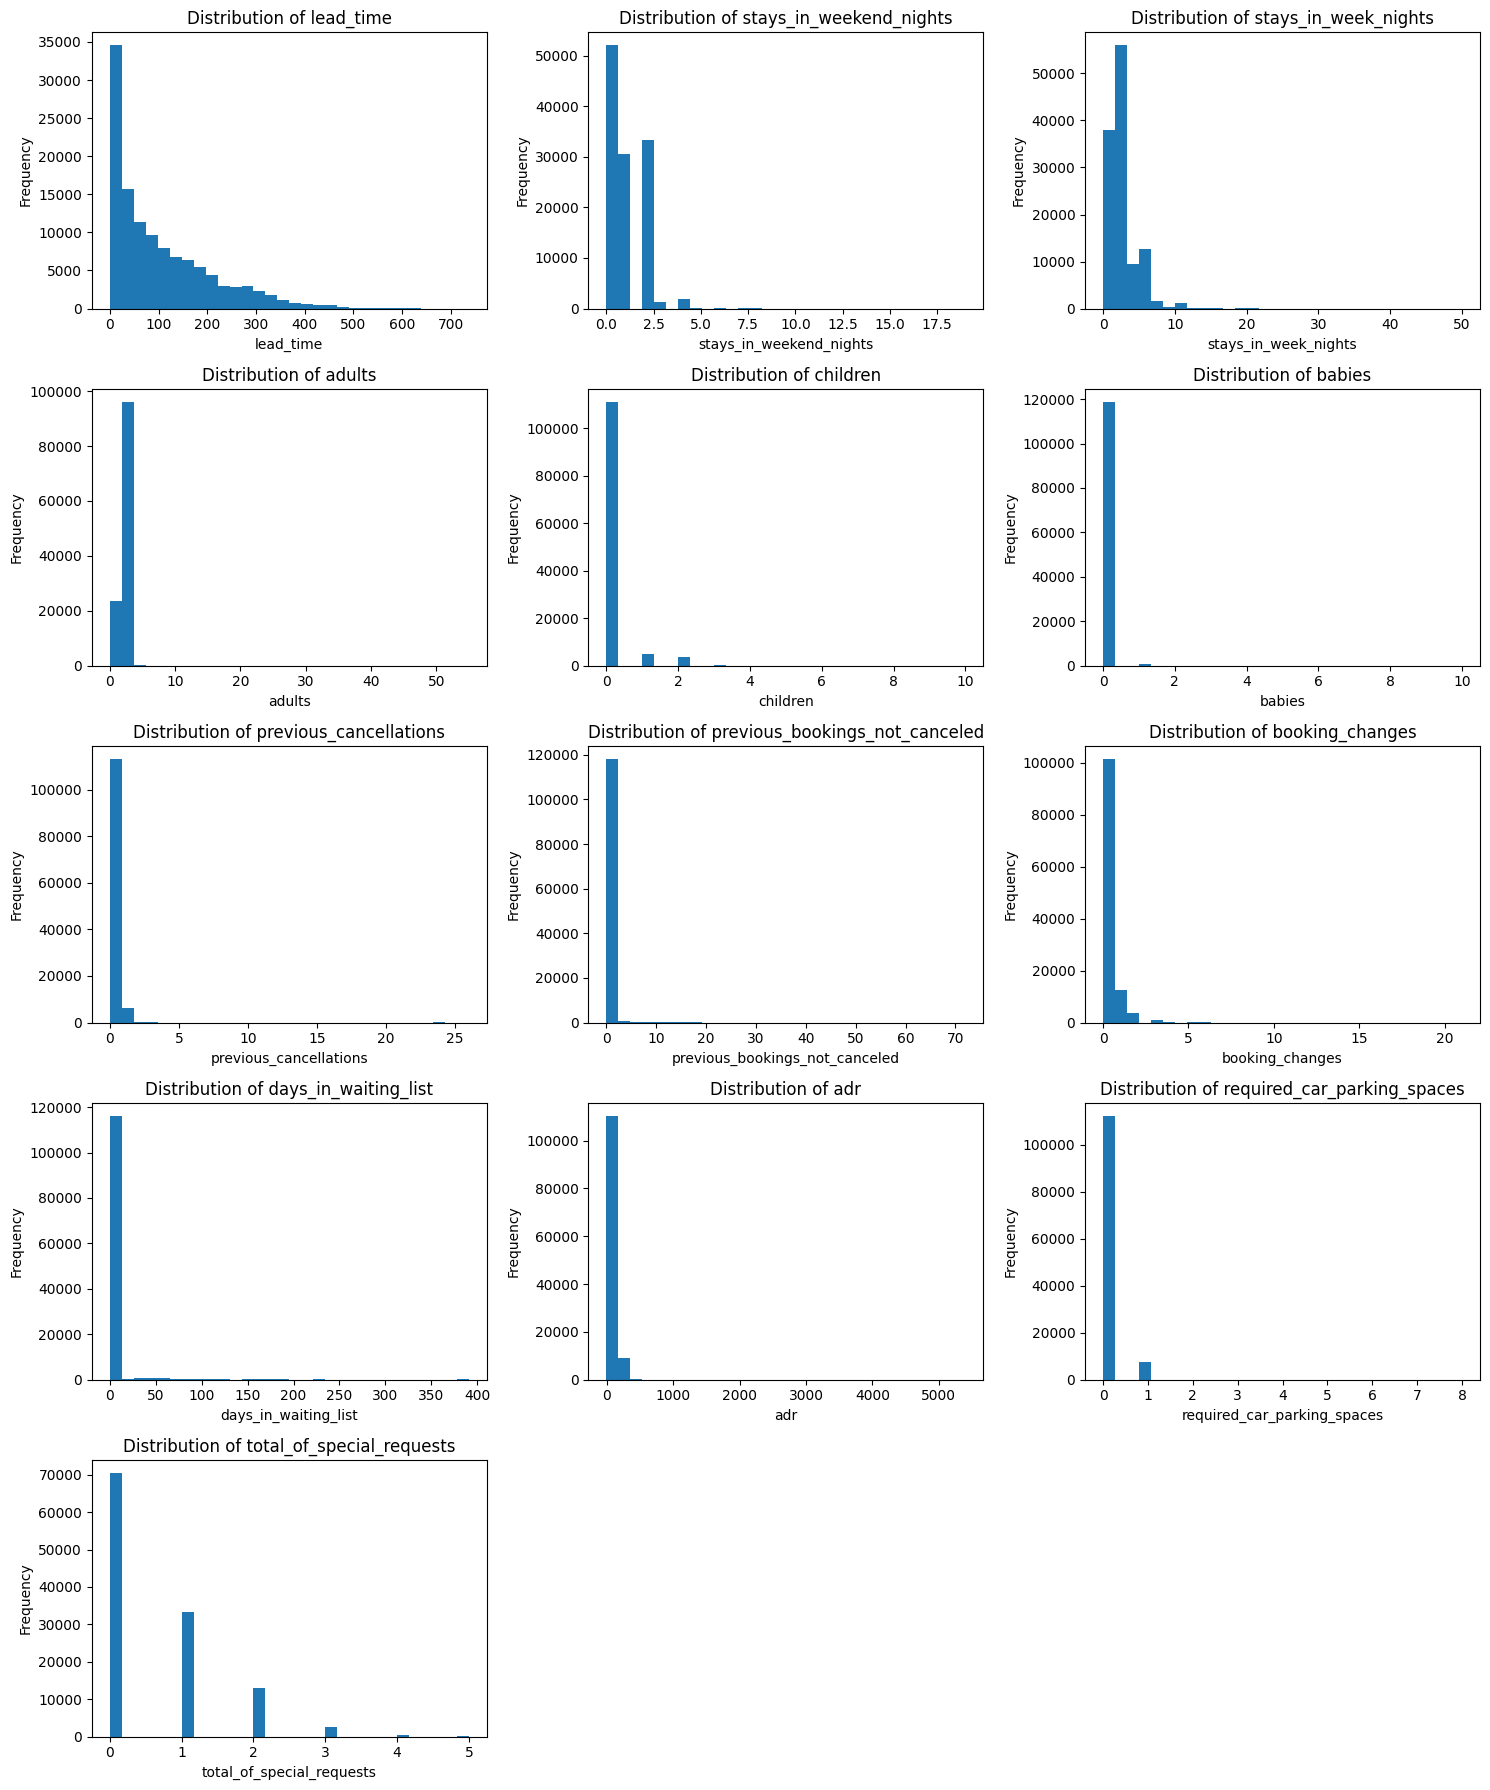

In [13]:
def classify_skewness(value):
    if value > 1:
        return "Strong right skew"
    if value > 0.5:
        return "Moderate right skew"
    if value < -1:
        return "Strong left skew"
    if value < -0.5:
        return "Moderate left skew"
    return "Approximately symmetric"

skewness_summary = pd.DataFrame({
    "Skewness": hotel_data[numeric_analysis_columns].skew()
})
skewness_summary["Interpretation"] = skewness_summary["Skewness"].apply(classify_skewness)
skewness_summary = skewness_summary.sort_values("Skewness", ascending=False).round(3)

display(skewness_summary)

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for axis, column in zip(axes, numeric_analysis_columns):
    axis.hist(hotel_data[column].dropna(), bins=30)
    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel(column)
    axis.set_ylabel("Frequency")

for axis in axes[len(numeric_analysis_columns):]:
    axis.remove()

plt.tight_layout()
plt.show()

### Three Univariate Outlier Detection Methods

The assignment requires three methods. The analysis uses:

1. **IQR rule** (`Q1 - 1.5×IQR`, `Q3 + 1.5×IQR`)
2. **Standard Z-score** (`|z| > 3`)
3. **Modified Z-score based on MAD** (`|modified z| > 3.5`)

A method is marked as degenerate/not applicable when its scale term equals zero. This is important for zero-inflated discrete variables.

In [14]:
def detect_outliers_three_methods(dataframe, columns):
    results = []

    for column in columns:
        series = dataframe[column].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0 or pd.isna(iqr):
            iqr_count = np.nan
            iqr_status = "Degenerate (IQR = 0)"
        else:
            lower_iqr = q1 - 1.5 * iqr
            upper_iqr = q3 + 1.5 * iqr
            iqr_count = int(((series < lower_iqr) | (series > upper_iqr)).sum())
            iqr_status = "Calculated"

        std_value = series.std()
        if std_value == 0 or pd.isna(std_value):
            zscore_count = np.nan
            zscore_status = "Not applicable (Std = 0)"
        else:
            z_scores = (series - series.mean()) / std_value
            zscore_count = int((z_scores.abs() > 3).sum())
            zscore_status = "Calculated"

        median_value = series.median()
        mad_value = float(np.median(np.abs(series - median_value)))
        if mad_value == 0 or pd.isna(mad_value):
            modified_z_count = np.nan
            modified_z_status = "Degenerate (MAD = 0)"
        else:
            modified_z_scores = 0.6745 * (series - median_value) / mad_value
            modified_z_count = int((modified_z_scores.abs() > 3.5).sum())
            modified_z_status = "Calculated"

        results.append({
            "Column": column,
            "IQR Outliers": iqr_count,
            "IQR Status": iqr_status,
            "Z-score Outliers": zscore_count,
            "Z-score Status": zscore_status,
            "Modified Z-score Outliers": modified_z_count,
            "Modified Z-score Status": modified_z_status,
        })

    return pd.DataFrame(results)

outlier_summary = detect_outliers_three_methods(hotel_data, numeric_analysis_columns)
display(outlier_summary)

,Column,IQR Outliers,IQR Status,Z-score Outliers,Z-score Status,Modified Z-score Outliers,Modified Z-score Status
0,lead_time,3005.0,Calculated,1454,Calculated,2802.0,Calculated
1,stays_in_weekend_nights,265.0,Calculated,2199,Calculated,112.0,Calculated
2,stays_in_week_nights,3354.0,Calculated,1669,Calculated,2325.0,Calculated
3,adults,NaN,Degenerate (IQR = 0),481,Calculated,NaN,Degenerate (MAD = 0)
4,children,NaN,Degenerate (IQR = 0),3729,Calculated,NaN,Degenerate (MAD = 0)
5,babies,NaN,Degenerate (IQR = 0),917,Calculated,NaN,Degenerate (MAD = 0)
6,previous_cancellations,NaN,Degenerate (IQR = 0),317,Calculated,NaN,Degenerate (MAD = 0)
7,previous_bookings_not_canceled,NaN,Degenerate (IQR = 0),936,Calculated,NaN,Degenerate (MAD = 0)
8,booking_changes,NaN,Degenerate (IQR = 0),1570,Calculated,NaN,Degenerate (MAD = 0)
9,days_in_waiting_list,NaN,Degenerate (IQR = 0),1871,Calculated,NaN,Degenerate (MAD = 0)


### Outlier-Method Interpretation

The methods produce different results because they rely on different assumptions.

- **IQR** is robust to extreme values and is useful for skewed continuous variables when `IQR > 0`.
- **Z-score** uses the mean and standard deviation and is most interpretable for approximately symmetric distributions; strong skewness can reduce its usefulness.
- **Modified Z-score** uses median and MAD and is robust to extreme observations, but it degenerates when `MAD = 0`.
- Several variables here are discrete and heavily concentrated at zero. For some of them, `IQR = 0` and/or `MAD = 0`, so a mechanical outlier rule is not informative.

Therefore, no single method should be applied blindly to every variable. For skewed continuous variables such as `lead_time` and `adr`, robust rules are useful; for zero-inflated count variables, domain meaning should be considered together with statistical rules. An outlier is not automatically an error.

## 5.2 Categorical Variables

In [15]:
categorical_analysis_columns = [
    "hotel",
    "is_canceled",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "is_repeated_guest",
    "customer_type",
    "reservation_status",
]

top_k = 5
categorical_summary_rows = []
top_k_tables = {}

for column in categorical_analysis_columns:
    clean_series = hotel_data[column].astype("object").where(hotel_data[column].notna(), "Missing")
    value_counts = clean_series.value_counts()
    percentages = clean_series.value_counts(normalize=True).mul(100)

    categorical_summary_rows.append({
        "Column": column,
        "Unique Values": clean_series.nunique(dropna=False),
        "Most Frequent Value": value_counts.index[0],
        "Frequency": int(value_counts.iloc[0]),
        "Percentage (%)": round(percentages.iloc[0], 2),
    })

    top_k_tables[column] = pd.DataFrame({
        "Value": value_counts.head(top_k).index,
        "Count": value_counts.head(top_k).values,
        "Percentage (%)": percentages.head(top_k).round(2).values,
    })

categorical_summary = pd.DataFrame(categorical_summary_rows)
display(categorical_summary)

for column in categorical_analysis_columns:
    print(f"Top {top_k} values — {column}")
    display(top_k_tables[column])

,Column,Unique Values,Most Frequent Value,Frequency,Percentage (%)
0,hotel,2,City Hotel,79330,66.45
1,is_canceled,2,0,75166,62.96
2,arrival_date_month,12,August,13877,11.62
3,meal,5,BB,92310,77.32
4,country,178,PRT,48590,40.70
5,market_segment,8,Online TA,56477,47.30
6,distribution_channel,5,TA/TO,97870,81.98
7,reserved_room_type,10,A,85994,72.03
8,assigned_room_type,12,A,74053,62.03
9,deposit_type,3,No Deposit,104641,87.65


Top 5 values — hotel


,Value,Count,Percentage (%)
0,City Hotel,79330,66.45
1,Resort Hotel,40060,33.55


Top 5 values — is_canceled


,Value,Count,Percentage (%)
0,0,75166,62.96
1,1,44224,37.04


...

,Value,Count,Percentage (%)
0,0,115580,96.81
1,1,3810,3.19


Top 5 values — customer_type


,Value,Count,Percentage (%)
0,Transient,89613,75.06
1,Transient-Party,25124,21.04
2,Contract,4076,3.41
3,Group,577,0.48


Top 5 values — reservation_status


,Value,Count,Percentage (%)
0,Check-Out,75166,62.96
1,Canceled,43017,36.03
2,No-Show,1207,1.01


### Minimum Number of Categories Needed to Cover P% of the Data

The assignment leaves `P` unspecified. This notebook uses **P = 80%**, a clear and reproducible threshold.

In [16]:
coverage_threshold = 0.80
coverage_results = []
coverage_tables = {}

for column in categorical_analysis_columns:
    clean_series = hotel_data[column].astype("object").where(hotel_data[column].notna(), "Missing")
    value_counts = clean_series.value_counts()
    proportions = value_counts / len(clean_series)
    cumulative = proportions.cumsum()

    minimum_categories = int((cumulative < coverage_threshold).sum() + 1)

    coverage_results.append({
        "Column": column,
        "Minimum Categories for 80%": minimum_categories,
        "Covered Percentage (%)": round(cumulative.iloc[minimum_categories - 1] * 100, 2),
    })

    coverage_tables[column] = pd.DataFrame({
        "Value": value_counts.head(minimum_categories).index,
        "Count": value_counts.head(minimum_categories).values,
        "Percentage (%)": (proportions.head(minimum_categories) * 100).round(2).values,
        "Cumulative Percentage (%)": (cumulative.head(minimum_categories) * 100).round(2).values,
    })

coverage_summary = pd.DataFrame(coverage_results)
display(coverage_summary)

for column in categorical_analysis_columns:
    print(f"Categories covering at least 80% — {column}")
    display(coverage_tables[column])

,Column,Minimum Categories for 80%,Covered Percentage (%)
0,hotel,2,100.00
1,is_canceled,2,100.00
2,arrival_date_month,9,83.66
3,meal,2,89.43
4,country,8,80.80
5,market_segment,3,84.18
6,distribution_channel,1,81.98
7,reserved_room_type,2,88.11
8,assigned_room_type,2,83.24
9,deposit_type,1,87.65


Categories covering at least 80% — hotel


,Value,Count,Percentage (%),Cumulative Percentage (%)
0,City Hotel,79330,66.45,66.45
1,Resort Hotel,40060,33.55,100.00


Categories covering at least 80% — is_canceled


,Value,Count,Percentage (%),Cumulative Percentage (%)
0,0,75166,62.96,62.96
1,1,44224,37.04,100.00


...

,Value,Count,Percentage (%),Cumulative Percentage (%)
0,0,115580,96.81,96.81


Categories covering at least 80% — customer_type


,Value,Count,Percentage (%),Cumulative Percentage (%)
0,Transient,89613,75.06,75.06
1,Transient-Party,25124,21.04,96.10


Categories covering at least 80% — reservation_status


,Value,Count,Percentage (%),Cumulative Percentage (%)
0,Check-Out,75166,62.96,62.96
1,Canceled,43017,36.03,98.99


### Rare Categories

A category is defined here as **rare when it represents less than 1% of the rows** in that variable. The threshold is an analytical choice, not a universal rule.

In [17]:
rare_threshold = 0.01
rare_summary_rows = []
rare_examples = {}

for column in categorical_analysis_columns:
    clean_series = hotel_data[column].astype("object").where(hotel_data[column].notna(), "Missing")
    counts = clean_series.value_counts()
    percentages = clean_series.value_counts(normalize=True) * 100
    rare_mask = percentages < rare_threshold * 100
    rare_values = percentages[rare_mask].index

    rare_row_count = int(counts.loc[rare_values].sum()) if len(rare_values) else 0

    rare_summary_rows.append({
        "Column": column,
        "Number of Rare Categories": len(rare_values),
        "Rows in Rare Categories": rare_row_count,
        "Percentage of Rows (%)": round(rare_row_count / len(clean_series) * 100, 2),
    })

    rare_table = pd.DataFrame({
        "Rare Category": counts.loc[rare_values].index,
        "Count": counts.loc[rare_values].values,
        "Percentage (%)": percentages.loc[rare_values].round(4).values,
    }).sort_values("Count", ascending=False)

    rare_examples[column] = rare_table.head(20)

rare_category_summary = pd.DataFrame(rare_summary_rows)
display(rare_category_summary)

for column, table in rare_examples.items():
    if not table.empty:
        print(f"Up to 20 rare-category examples — {column}")
        display(table)

,Column,Number of Rare Categories,Rows in Rare Categories,Percentage of Rows (%)
0,hotel,0,0,0.00
1,is_canceled,0,0,0.00
2,arrival_date_month,0,0,0.00
3,meal,2,1967,1.65
4,country,164,12221,10.24
5,market_segment,3,982,0.82
6,distribution_channel,2,198,0.17
7,reserved_room_type,5,2669,2.24
8,assigned_room_type,5,1367,1.14
9,deposit_type,1,162,0.14


Up to 20 rare-category examples — meal


,Rare Category,Count,Percentage (%)
0,Undefined,1169,0.9791
1,FB,798,0.6684


Up to 20 rare-category examples — country


,Rare Category,Count,Percentage (%)
0,SWE,1024,0.8577
1,CHN,999,0.8368
2,POL,919,0.7697
3,ISR,669,0.5603
4,RUS,632,0.5294
5,NOR,607,0.5084
6,ROU,500,0.4188
7,Missing,488,0.4087
8,FIN,447,0.3744
9,DNK,435,0.3644


...

,Rare Category,Count,Percentage (%)
0,H,712,0.5964
1,I,363,0.3040
2,K,279,0.2337
3,P,12,0.0101
4,L,1,0.0008


Up to 20 rare-category examples — deposit_type


,Rare Category,Count,Percentage (%)
0,Refundable,162,0.1357


Up to 20 rare-category examples — customer_type


,Rare Category,Count,Percentage (%)
0,Group,577,0.4833


### Categorical Interpretation

- Rare categories should not be removed automatically; low frequency does not imply low information value.
- In a high-cardinality field such as `country`, grouping very rare categories into `Other` may improve visualization or modeling, but this loses geographic detail.
- Business-sensitive categories should remain separate when their meaning matters.
- Binary variables such as `is_canceled` and `is_repeated_guest` are analyzed as categorical despite being stored numerically.

### Do Central Measures Represent the Data Well?

Not always. Many numerical variables are strongly skewed and contain extreme values. For variables such as `lead_time` and `adr`, the **mean alone can be pulled by the long right tail**, so the median and robust spread measures such as IQR/MAD provide important additional context. For zero-inflated count variables, even median and IQR may collapse to zero and fail to describe the minority of positive cases. Therefore, central measures should be interpreted together with distributions, quantiles, and domain context rather than used in isolation.

# 6. Correlations and Relationships

## 6.1 Numerical–Numerical Relationships

Pearson, Spearman, and Kendall correlations are calculated on the same meaningful numerical variables.

In [18]:
correlation_data = hotel_data[numeric_analysis_columns].copy()

pearson_correlation = correlation_data.corr(method="pearson")
spearman_correlation = correlation_data.corr(method="spearman")
kendall_correlation = correlation_data.corr(method="kendall")


def get_strongest_correlations(correlation_matrix, top_n=8):
    upper_triangle = np.triu(np.ones(correlation_matrix.shape, dtype=bool), k=1)
    pairs = correlation_matrix.where(upper_triangle).stack().reset_index()
    pairs.columns = ["Variable 1", "Variable 2", "Correlation"]
    pairs["Absolute Correlation"] = pairs["Correlation"].abs()
    return (
        pairs.sort_values("Absolute Correlation", ascending=False)
        .head(top_n)
        .drop(columns="Absolute Correlation")
        .reset_index(drop=True)
        .round(3)
    )

print("Strongest Pearson correlations:")
display(get_strongest_correlations(pearson_correlation))

print("Strongest Spearman correlations:")
display(get_strongest_correlations(spearman_correlation))

print("Strongest Kendall correlations:")
display(get_strongest_correlations(kendall_correlation))

Strongest Pearson correlations:


,Variable 1,Variable 2,Correlation
0,stays_in_weekend_nights,stays_in_week_nights,0.499
1,children,adr,0.325
2,adults,adr,0.231
3,adr,total_of_special_requests,0.172
4,lead_time,days_in_waiting_list,0.170
5,lead_time,stays_in_week_nights,0.166
6,previous_cancellations,previous_bookings_not_canceled,0.153
7,adults,total_of_special_requests,0.123


Strongest Spearman correlations:


,Variable 1,Variable 2,Correlation
0,lead_time,stays_in_week_nights,0.296
1,adults,adr,0.280
2,children,adr,0.265
3,stays_in_weekend_nights,stays_in_week_nights,0.238
4,adults,previous_bookings_not_canceled,-0.210
5,adr,total_of_special_requests,0.196
6,lead_time,adults,0.192
7,lead_time,previous_bookings_not_canceled,-0.189


Strongest Kendall correlations:


,Variable 1,Variable 2,Correlation
0,adults,adr,0.227
1,lead_time,stays_in_week_nights,0.218
2,children,adr,0.217
3,adults,previous_bookings_not_canceled,-0.204
4,stays_in_weekend_nights,stays_in_week_nights,0.199
5,adr,total_of_special_requests,0.155
6,lead_time,previous_bookings_not_canceled,-0.154
7,lead_time,adults,0.153


### Correlation Method Differences

- **Pearson** measures linear association using raw values and is sensitive to extreme observations.
- **Spearman** measures monotonic association using ranks and is less sensitive to skewness and outliers.
- **Kendall** also uses ranks and measures pairwise concordance; it is often more conservative in magnitude.

The values differ because many variables in this dataset are skewed, discrete, or contain extreme observations. A relationship can be monotonic without being strongly linear, so rank-based correlations may tell a different story from Pearson.

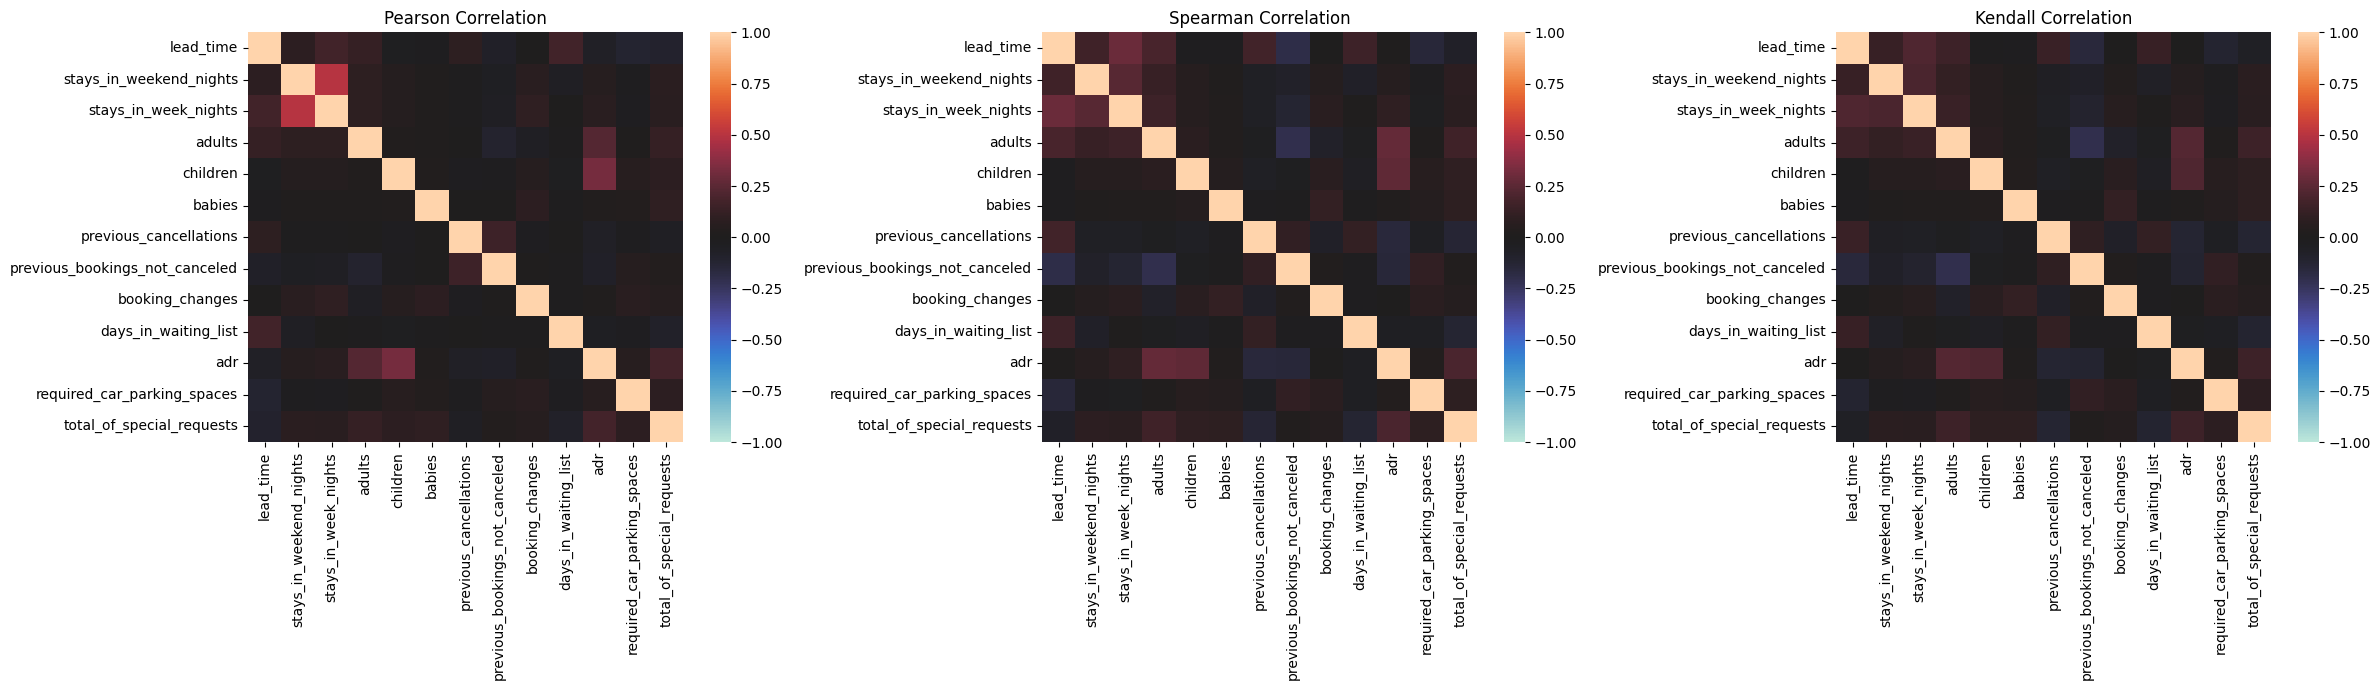

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for axis, (title, matrix) in zip(
    axes,
    [
        ("Pearson Correlation", pearson_correlation),
        ("Spearman Correlation", spearman_correlation),
        ("Kendall Correlation", kendall_correlation),
    ],
):
    sns.heatmap(matrix, ax=axis, center=0, vmin=-1, vmax=1)
    axis.set_title(title)

plt.tight_layout()
plt.show()

### Scatterplots for Selected Numerical Relationships

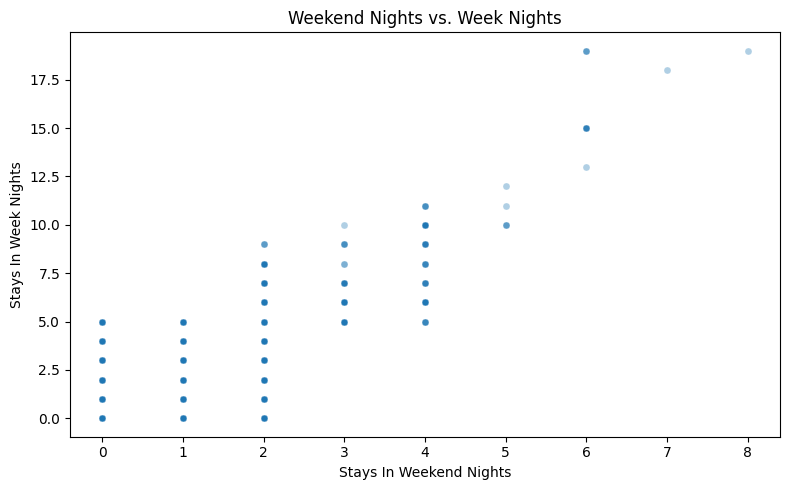

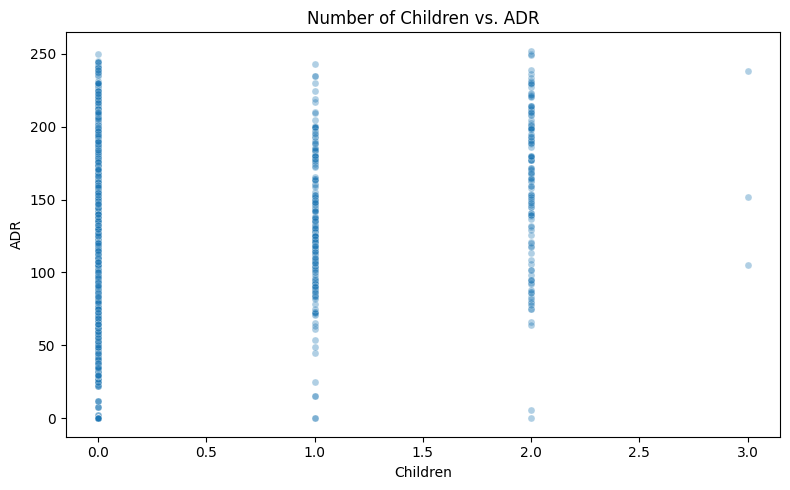

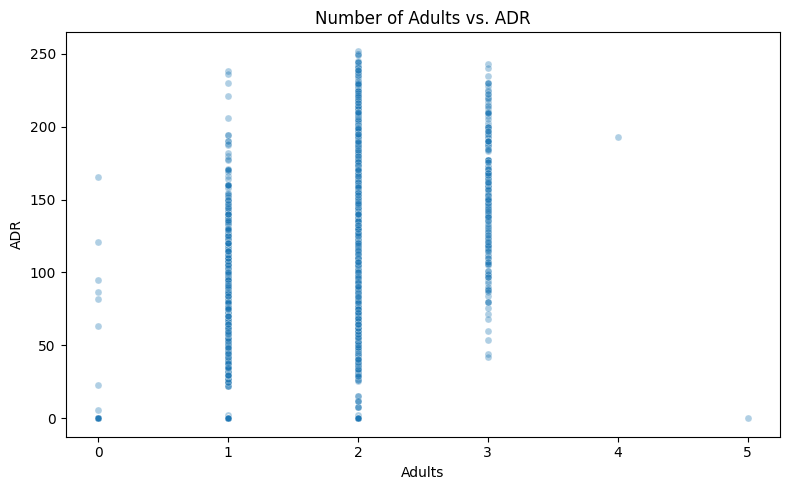

In [20]:
scatter_sample = hotel_data.sample(n=min(5000, len(hotel_data)), random_state=42).copy()
adr_upper_limit = hotel_data.loc[hotel_data["adr"] >= 0, "adr"].quantile(0.99)
scatter_sample_adr = scatter_sample[scatter_sample["adr"].between(0, adr_upper_limit)].copy()

scatter_pairs = [
    ("stays_in_weekend_nights", "stays_in_week_nights", scatter_sample, "Weekend Nights vs. Week Nights"),
    ("children", "adr", scatter_sample_adr, "Number of Children vs. ADR"),
    ("adults", "adr", scatter_sample_adr, "Number of Adults vs. ADR"),
]

for x_column, y_column, plot_data, title in scatter_pairs:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=plot_data, x=x_column, y=y_column, alpha=0.35, s=25)
    plt.title(title)
    plt.xlabel(x_column.replace("_", " ").title())
    plt.ylabel("ADR" if y_column == "adr" else y_column.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

### Numerical-Relationship Interpretation

- Weekend-night and weekday-night stays show one of the clearer positive numerical relationships.
- ADR tends to increase somewhat with party composition variables such as adults and children, but the scatter is substantial.
- Most relationships are weak to moderate rather than extremely strong.
- Correlation is an association measure and does not establish causation.

## 6.2 Categorical–Categorical Relationships

Frequency tables are examined primarily against cancellation status. Cramér's V is also calculated as an optional measure of association strength.

In [21]:
def cramers_v_from_table(contingency_table):
    chi2_statistic, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    min_dimension = min(contingency_table.shape) - 1
    if min_dimension <= 0:
        return np.nan
    return np.sqrt(chi2_statistic / (n * min_dimension))

categorical_pairs = [
    ("hotel", "is_canceled"),
    ("market_segment", "is_canceled"),
    ("deposit_type", "is_canceled"),
    ("customer_type", "is_canceled"),
]

association_strength = []

for row_variable, column_variable in categorical_pairs:
    frequency_table = pd.crosstab(hotel_data[row_variable], hotel_data[column_variable])
    row_percentage_table = pd.crosstab(
        hotel_data[row_variable],
        hotel_data[column_variable],
        normalize="index",
    ).mul(100).round(2)

    print(f"Frequency table — {row_variable} vs. {column_variable}")
    display(frequency_table)
    print("Row percentages (%):")
    display(row_percentage_table)

    association_strength.append({
        "Variable 1": row_variable,
        "Variable 2": column_variable,
        "Cramer's V": round(cramers_v_from_table(frequency_table), 3),
    })

print("Optional Cramer's V summary:")
display(pd.DataFrame(association_strength))

Frequency table — hotel vs. is_canceled


is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


Row percentages (%):


is_canceled,0,1
hotel,,
City Hotel,58.27,41.73
Resort Hotel,72.24,27.76


Frequency table — market_segment vs. is_canceled


...

is_canceled,0,1
customer_type,,
Contract,2814,1262
Group,518,59
Transient,53099,36514
Transient-Party,18735,6389


Row percentages (%):


is_canceled,0,1
customer_type,,
Contract,69.04,30.96
Group,89.77,10.23
Transient,59.25,40.75
Transient-Party,74.57,25.43


Optional Cramer's V summary:


,Variable 1,Variable 2,Cramer's V
0,hotel,is_canceled,0.137
1,market_segment,is_canceled,0.267
2,deposit_type,is_canceled,0.481
3,customer_type,is_canceled,0.136


### Categorical-Relationship Interpretation

- Cancellation rates differ between City Hotel and Resort Hotel.
- Market segments show substantial differences in cancellation behavior.
- `deposit_type` has a particularly strong observed association with cancellation status. This result is counterintuitive and should be investigated for process effects rather than interpreted causally.
- Customer types also differ in their cancellation rates.

These tables reveal associations, not causal effects.

### Binning: Numerical–Categorical Relationships

Numerical variables are converted into interpretable groups to compare them with the binary categorical outcome `is_canceled`.

In [22]:
binned_data = hotel_data.copy()

lead_time_bins = [-1, 7, 30, 90, 180, 365, np.inf]
lead_time_labels = [
    "0-7 days",
    "8-30 days",
    "31-90 days",
    "91-180 days",
    "181-365 days",
    "More than 365 days",
]

binned_data["lead_time_group"] = pd.cut(
    binned_data["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels,
)

lead_time_cancellation = (
    binned_data.groupby("lead_time_group", observed=False)
    .agg(Bookings=("is_canceled", "size"), Cancellation_Rate=("is_canceled", "mean"))
    .reset_index()
)
lead_time_cancellation["Cancellation Rate (%)"] = (
    lead_time_cancellation["Cancellation_Rate"] * 100
).round(2)
lead_time_cancellation = lead_time_cancellation.drop(columns="Cancellation_Rate")

valid_adr_data = binned_data[binned_data["adr"] >= 0].copy()
valid_adr_data["adr_group"] = pd.qcut(
    valid_adr_data["adr"],
    q=4,
    labels=["Low ADR", "Medium ADR", "High ADR", "Very High ADR"],
)

adr_cancellation = (
    valid_adr_data.groupby("adr_group", observed=False)
    .agg(
        Bookings=("is_canceled", "size"),
        Median_ADR=("adr", "median"),
        Cancellation_Rate=("is_canceled", "mean"),
    )
    .reset_index()
)
adr_cancellation["Median_ADR"] = adr_cancellation["Median_ADR"].round(2)
adr_cancellation["Cancellation Rate (%)"] = (
    adr_cancellation["Cancellation_Rate"] * 100
).round(2)
adr_cancellation = adr_cancellation.drop(columns="Cancellation_Rate")

print("Lead-time bins vs. cancellation:")
display(lead_time_cancellation)

print("ADR quartiles vs. cancellation:")
display(adr_cancellation)

Lead-time bins vs. cancellation:


,lead_time_group,Bookings,Cancellation Rate (%)
0,0-7 days,19746,9.63
1,8-30 days,18960,27.86
2,31-90 days,29553,37.70
3,91-180 days,26439,44.71
4,181-365 days,21544,55.45
5,More than 365 days,3148,67.66


ADR quartiles vs. cancellation:


,adr_group,Bookings,Median_ADR,Cancellation Rate (%)
0,Low ADR,29869,56.10,33.43
1,Medium ADR,29828,81.00,36.91
2,High ADR,30508,108.90,39.17
3,Very High ADR,29184,156.03,38.64


### Binning Interpretation

The lead-time groups show a strong pattern: bookings made farther in advance have substantially higher observed cancellation rates. ADR groups show smaller differences. This suggests that booking horizon is more strongly associated with cancellation behavior than broad ADR level in this dataset.

Again, the pattern is associative and does not establish causality.

## 6.3 Graphs

The assignment requests informative plots with titles, axes, legends when needed, and written insights. Scatterplots and correlation heatmaps were already shown above; the remaining requested graph types follow here.

### Histogram

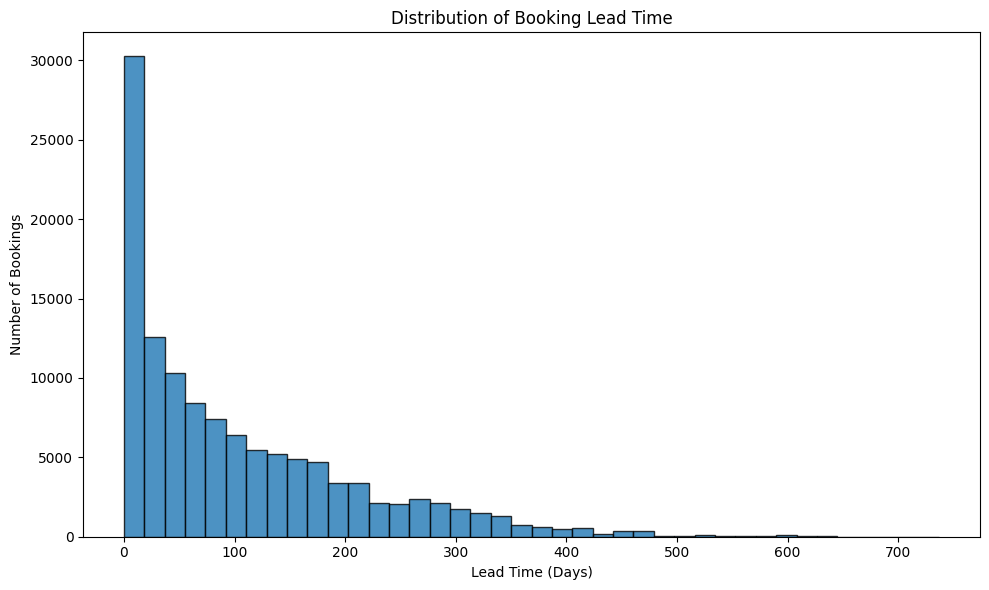

Lead-time skewness: 1.35
Lead-time mean: 104.01 days
Lead-time median: 69 days


In [23]:
lead_time_values = hotel_data["lead_time"].dropna()

plt.figure(figsize=(10, 6))
plt.hist(lead_time_values, bins=40, edgecolor="black", alpha=0.8)
plt.title("Distribution of Booking Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

print(f"Lead-time skewness: {lead_time_values.skew():.2f}")
print(f"Lead-time mean: {lead_time_values.mean():.2f} days")
print(f"Lead-time median: {lead_time_values.median():.0f} days")

**Histogram insight:** Lead time is right-skewed. The mean is above the median because a minority of reservations are made very far in advance. This supports using robust statistics in addition to the mean.

### Bar Chart

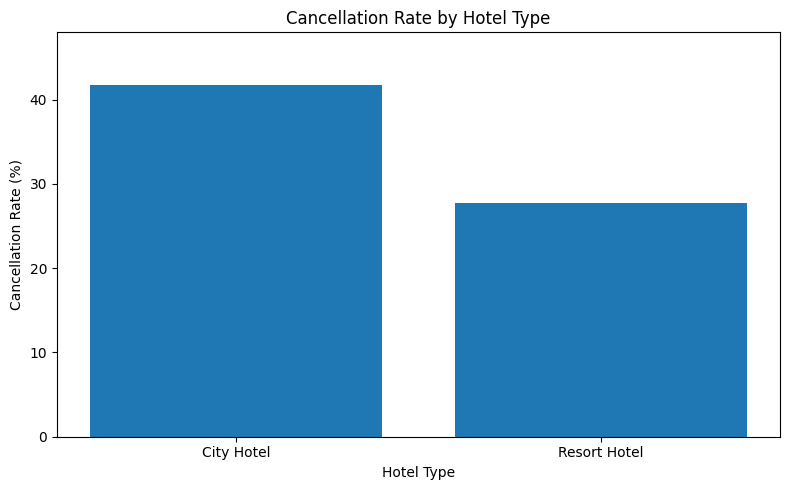

,Cancellation Rate (%)
hotel,
City Hotel,41.73
Resort Hotel,27.76


In [24]:
cancellation_by_hotel = hotel_data.groupby("hotel")["is_canceled"].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(cancellation_by_hotel.index, cancellation_by_hotel.values)
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.ylim(0, cancellation_by_hotel.max() * 1.15)
plt.tight_layout()
plt.show()

display(cancellation_by_hotel.rename("Cancellation Rate (%)").round(2).to_frame())

**Bar-chart insight:** City Hotel has a clearly higher observed cancellation rate than Resort Hotel. This is an association and should not be interpreted as a causal effect of hotel type.

### Boxplot

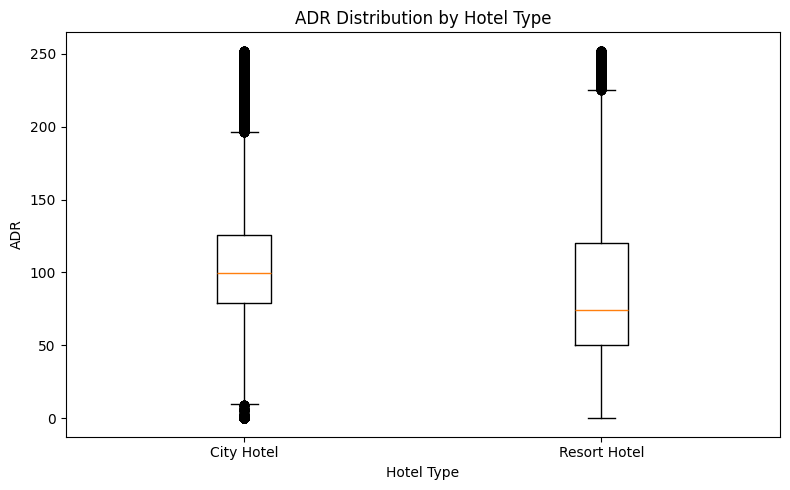

In [25]:
valid_adr_plot_data = hotel_data[hotel_data["adr"] >= 0].copy()
adr_plot_upper_limit = valid_adr_plot_data["adr"].quantile(0.99)
boxplot_data = valid_adr_plot_data[valid_adr_plot_data["adr"] <= adr_plot_upper_limit]

hotel_order = ["City Hotel", "Resort Hotel"]
adr_groups = [
    boxplot_data.loc[boxplot_data["hotel"] == hotel, "adr"].dropna().values
    for hotel in hotel_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(adr_groups, tick_labels=hotel_order, showfliers=True)
plt.title("ADR Distribution by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("ADR")
plt.tight_layout()
plt.show()

**Boxplot insight:** The hotels differ in both central ADR and spread. The display is limited to the 99th percentile only to prevent a small number of extreme prices from compressing the visualization; the original observations remain in the dataset.

### Violin Plot

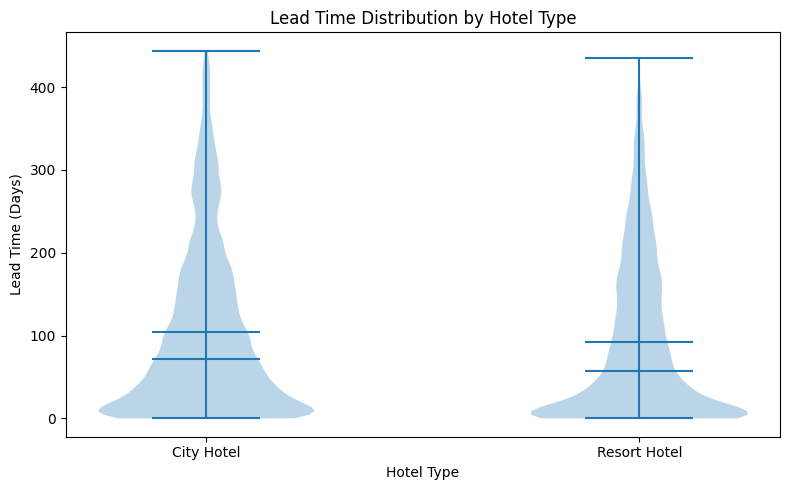

In [26]:
lead_time_plot_upper_limit = hotel_data["lead_time"].quantile(0.99)
violin_data = hotel_data[hotel_data["lead_time"] <= lead_time_plot_upper_limit]

lead_time_groups = [
    violin_data.loc[violin_data["hotel"] == hotel, "lead_time"].dropna().values
    for hotel in hotel_order
]

plt.figure(figsize=(8, 5))
plt.violinplot(lead_time_groups, showmeans=True, showmedians=True)
plt.xticks([1, 2], hotel_order)
plt.title("Lead Time Distribution by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Lead Time (Days)")
plt.tight_layout()
plt.show()

**Violin-plot insight:** Lead-time distributions differ between the two hotels and remain strongly asymmetric. The 99th-percentile visualization limit improves readability without deleting data from the analysis.

### Pie Chart

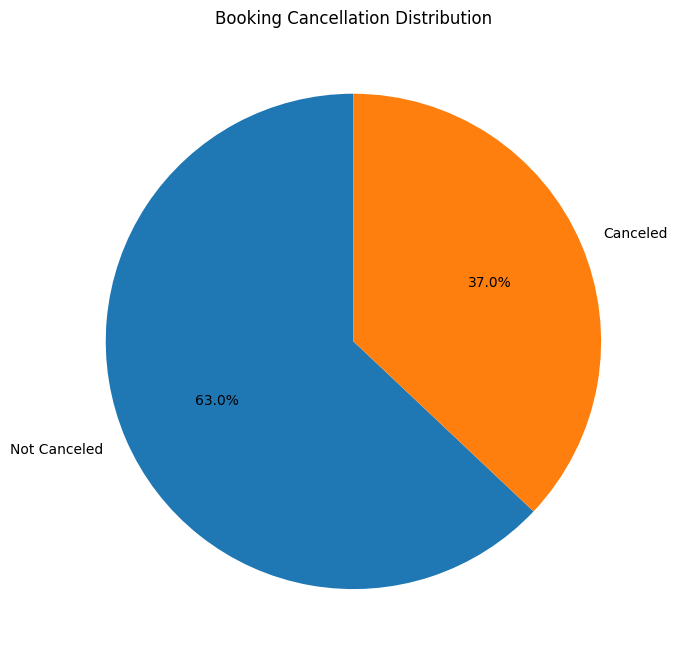

In [27]:
cancellation_counts = hotel_data["is_canceled"].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(
    cancellation_counts.values,
    labels=["Not Canceled", "Canceled"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Booking Cancellation Distribution")
plt.tight_layout()
plt.show()

**Pie-chart insight:** Cancellations represent a substantial share of the records rather than a rare event, making cancellation behavior an important operational feature of the dataset.

### Pairplot

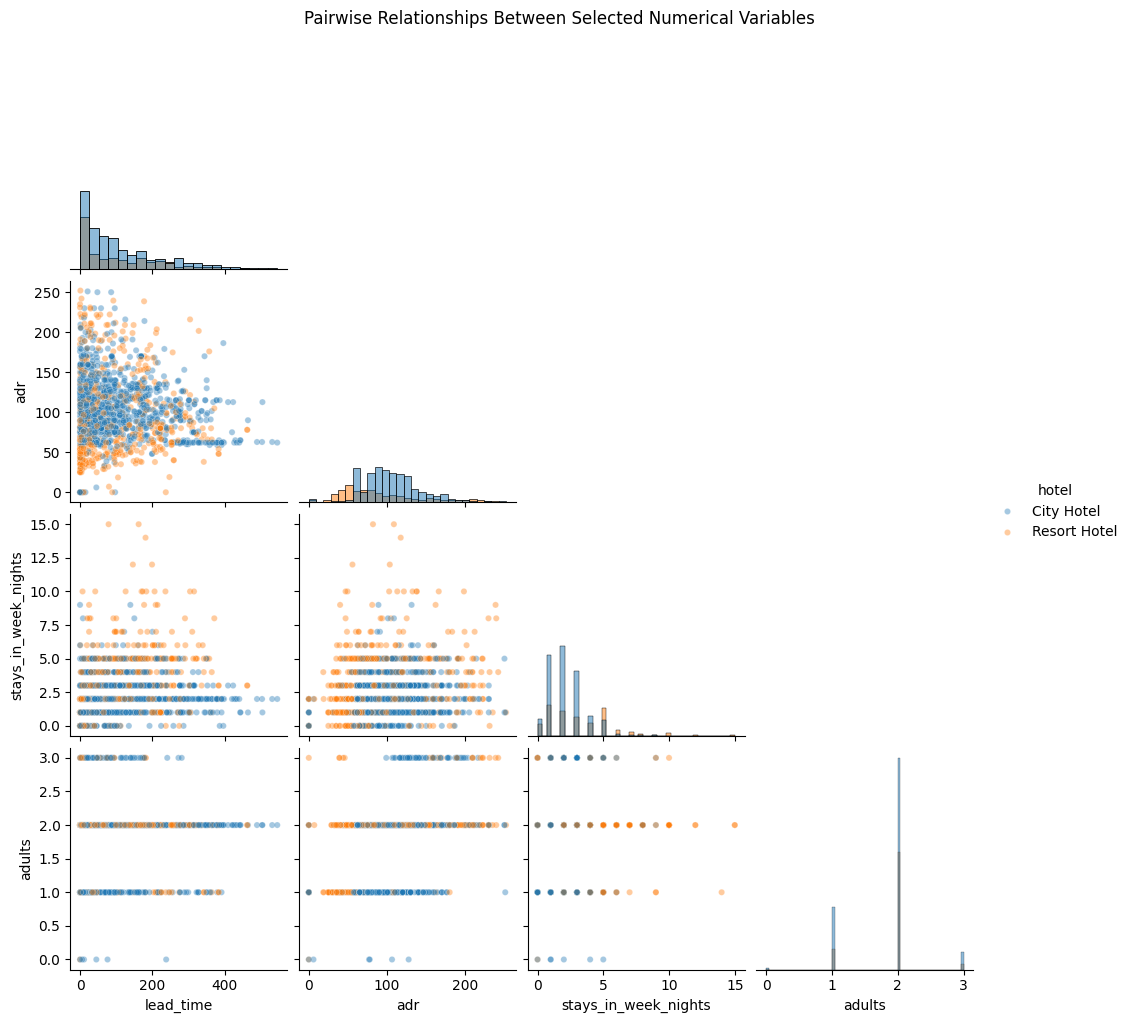

In [28]:
pairplot_columns = ["lead_time", "adr", "stays_in_week_nights", "adults", "hotel"]
pairplot_source = hotel_data[pairplot_columns].dropna().copy()
pairplot_source = pairplot_source[
    pairplot_source["adr"].between(0, adr_plot_upper_limit)
]
pairplot_data = pairplot_source.sample(
    n=min(1500, len(pairplot_source)),
    random_state=42,
)

pair_grid = sns.pairplot(
    pairplot_data,
    hue="hotel",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.4, "s": 20},
)
pair_grid.fig.suptitle(
    "Pairwise Relationships Between Selected Numerical Variables",
    y=1.02,
)
plt.show()

**Pairplot insight:** Most selected numerical relationships are not strongly linear, and the two hotel types overlap on many numerical characteristics. The sample is used only to keep the plot readable and does not change the statistical analyses.

### Heatmap

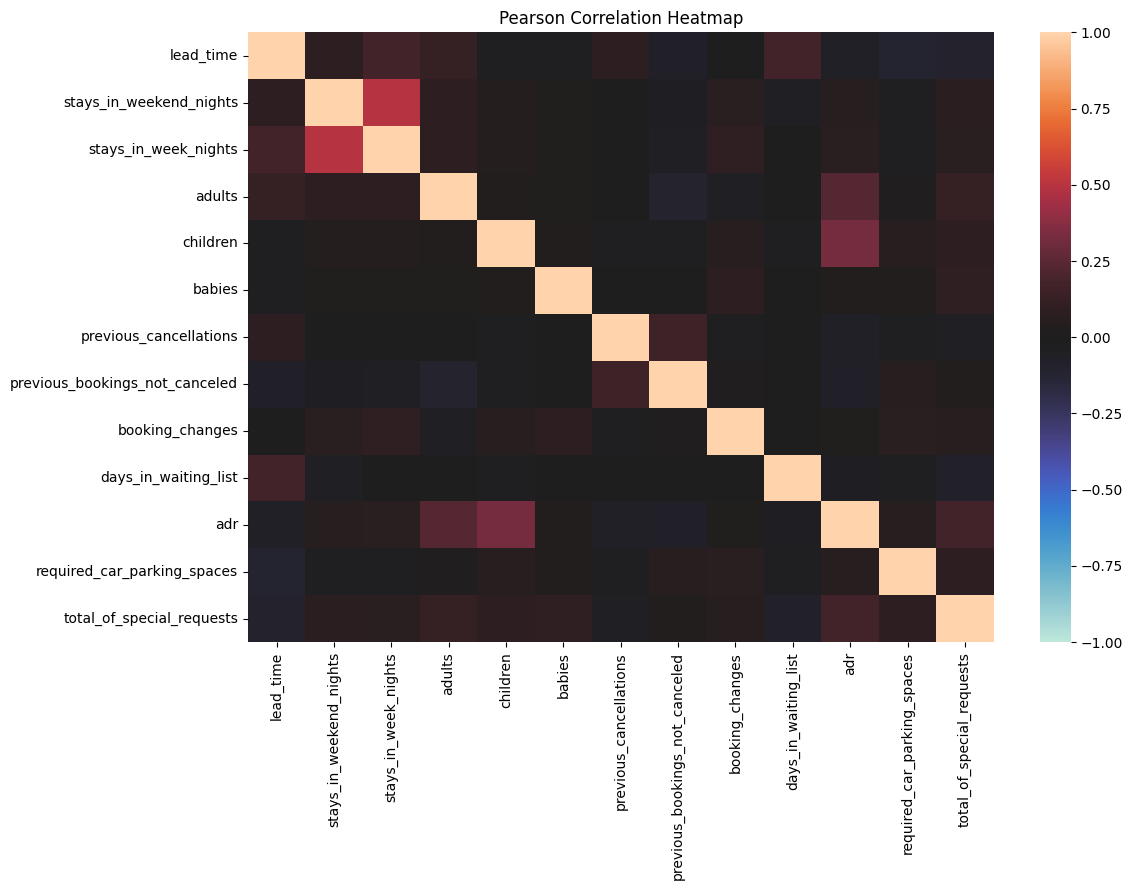

In [29]:
plt.figure(figsize=(12, 9))
sns.heatmap(pearson_correlation, center=0, vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

**Heatmap insight:** Most numerical associations are weak to moderate. No extremely high correlation dominates the numerical feature set, suggesting that the variables capture different aspects of booking behavior.

# 7. Index Analysis

In [30]:
index_summary = pd.DataFrame({
    "Property": [
        "Current index is unique",
        "Current index is time-based",
        "Current index is sorted",
        "Arrival date is unique",
        "Rows are sorted by arrival date",
    ],
    "Result": [
        hotel_data.index.is_unique,
        isinstance(hotel_data.index, pd.DatetimeIndex),
        hotel_data.index.is_monotonic_increasing,
        analysis_data["arrival_date"].is_unique,
        analysis_data["arrival_date"].is_monotonic_increasing,
    ],
})

display(index_summary)

analysis_data["arrival_month"] = analysis_data["arrival_date"].dt.to_period("M").dt.to_timestamp()

monthly_index_analysis = (
    analysis_data.groupby("arrival_month")
    .agg(
        Bookings=("is_canceled", "size"),
        Cancellation_Rate=("is_canceled", "mean"),
        Median_ADR=("adr", "median"),
    )
    .reset_index()
)
monthly_index_analysis["Cancellation Rate (%)"] = (
    monthly_index_analysis["Cancellation_Rate"] * 100
).round(2)
monthly_index_analysis["Median ADR"] = monthly_index_analysis["Median_ADR"].round(2)

display(
    monthly_index_analysis[[
        "arrival_month",
        "Bookings",
        "Cancellation Rate (%)",
        "Median ADR",
    ]]
)

,Property,Result
0,Current index is unique,True
1,Current index is time-based,False
2,Current index is sorted,True
3,Arrival date is unique,False
4,Rows are sorted by arrival date,False


,arrival_month,Bookings,Cancellation Rate (%),Median ADR
0,2015-07-01,2776,45.35,90.00
1,2015-08-01,3889,41.09,94.50
2,2015-09-01,5114,40.95,89.20
3,2015-10-01,4957,34.94,75.00
4,2015-11-01,2340,20.77,62.80
5,2015-12-01,2920,33.32,70.00
6,2016-01-01,2248,24.78,68.99
7,2016-02-01,3891,34.36,73.20
8,2016-03-01,4824,30.62,75.95
9,2016-04-01,5428,37.97,86.00


### Index Interpretation

- The current DataFrame index is unique and sorted, but it is only the default sequential pandas index and has no business meaning.
- The current index is not time-based.
- `arrival_date` is not unique because many reservations share the same arrival date.
- The source rows are not fully ordered by arrival date.
- Booking volume, cancellation rate, and ADR change over time, so the time dimension is analytically important.

A date-based index could be useful for time-series work, but it would naturally contain duplicate dates because multiple reservations occur each day.

# 8. Insights and Data Story

In [31]:
city_cancellation_rate = hotel_data.loc[
    hotel_data["hotel"] == "City Hotel", "is_canceled"
].mean() * 100
resort_cancellation_rate = hotel_data.loc[
    hotel_data["hotel"] == "Resort Hotel", "is_canceled"
].mean() * 100
non_refund_cancellation_rate = hotel_data.loc[
    hotel_data["deposit_type"] == "Non Refund", "is_canceled"
].mean() * 100
overall_cancellation_rate = hotel_data["is_canceled"].mean() * 100

lead_time_rates = (
    binned_data.groupby("lead_time_group", observed=False)["is_canceled"]
    .mean()
    .mul(100)
)
short_lead_rate = lead_time_rates.loc["0-7 days"]
long_lead_rate = lead_time_rates.loc["More than 365 days"]

print(f"Overall cancellation rate: {overall_cancellation_rate:.2f}%")
print(f"City Hotel cancellation rate: {city_cancellation_rate:.2f}%")
print(f"Resort Hotel cancellation rate: {resort_cancellation_rate:.2f}%")
print(f"0-7 day lead-time cancellation rate: {short_lead_rate:.2f}%")
print(f">365 day lead-time cancellation rate: {long_lead_rate:.2f}%")
print(f"Non Refund cancellation rate: {non_refund_cancellation_rate:.2f}%")

Overall cancellation rate: 37.04%
City Hotel cancellation rate: 41.73%
Resort Hotel cancellation rate: 27.76%
0-7 day lead-time cancellation rate: 9.63%
>365 day lead-time cancellation rate: 67.66%
Non Refund cancellation rate: 99.36%


## Main Insights

1. **Cancellation risk rises strongly with booking lead time.** Bookings made shortly before arrival have much lower observed cancellation rates than bookings made many months in advance. This is one of the clearest patterns in the dataset.

2. **Cancellation behavior differs by hotel type.** City Hotel has a noticeably higher observed cancellation rate than Resort Hotel, suggesting different booking contexts and customer behavior.

3. **Deposit type is strongly associated with cancellation status.** `Non Refund` reservations show an unusually high observed cancellation rate. This counterintuitive pattern should be investigated for business-process explanations rather than interpreted as causal.

4. **Cancellation is operationally important.** More than one third of all records are canceled bookings, so cancellation cannot be treated as a rare edge case.

## Biases and Risks

- The dataset represents only two hotels in Portugal and a limited historical period.
- Missingness is partly structured, particularly for `agent` and `company`.
- There is no unique booking identifier, making duplicate validation uncertain.
- Suspicious values such as negative ADR, zero guests, and zero-night stays can distort naive summaries.
- Numeric identifiers such as `agent` and `company` must not be treated as continuous quantities.

## Potential Engineering and Statistical Failure Points

- **Data leakage:** `reservation_status` directly reflects the final reservation outcome and must not be used as an input feature to predict `is_canceled`. `reservation_status_date` can also contain post-outcome information. Including either would produce unrealistically strong predictive performance.
- Removing all duplicate-looking rows without a unique booking ID could delete legitimate reservations.
- Mean imputation for identifier columns would create artificial IDs.
- Treating every statistical outlier as an error could remove genuine rare behavior.
- Large sample size can make small effects statistically significant; effect size and practical relevance should be considered.
- Relationships found here are observational associations and do not prove causation.

## What Was Learned

The analysis shows that hotel booking data is shaped not only by price but also by timing, booking channel, customer context, hotel type, and operational processes. It also reinforces that data is not an absolute truth: missingness, recording conventions, identifiers, temporal structure, and potential leakage must be understood before statistical conclusions or engineering decisions are made.

# 9. Bonus

## 9.1 Time Dependency and Calendar Context

Time is examined at both monthly and seasonal levels. Season is derived from the calendar, which adds known temporal context without claiming an external causal driver.

,arrival_month,Bookings,Cancellation Rate (%),Median ADR
0,2015-07-01,2776,45.35,90.00
1,2015-08-01,3889,41.09,94.50
2,2015-09-01,5114,40.95,89.20
3,2015-10-01,4957,34.94,75.00
4,2015-11-01,2340,20.77,62.80
5,2015-12-01,2920,33.32,70.00
6,2016-01-01,2248,24.78,68.99
7,2016-02-01,3891,34.36,73.20
8,2016-03-01,4824,30.62,75.95
9,2016-04-01,5428,37.97,86.00


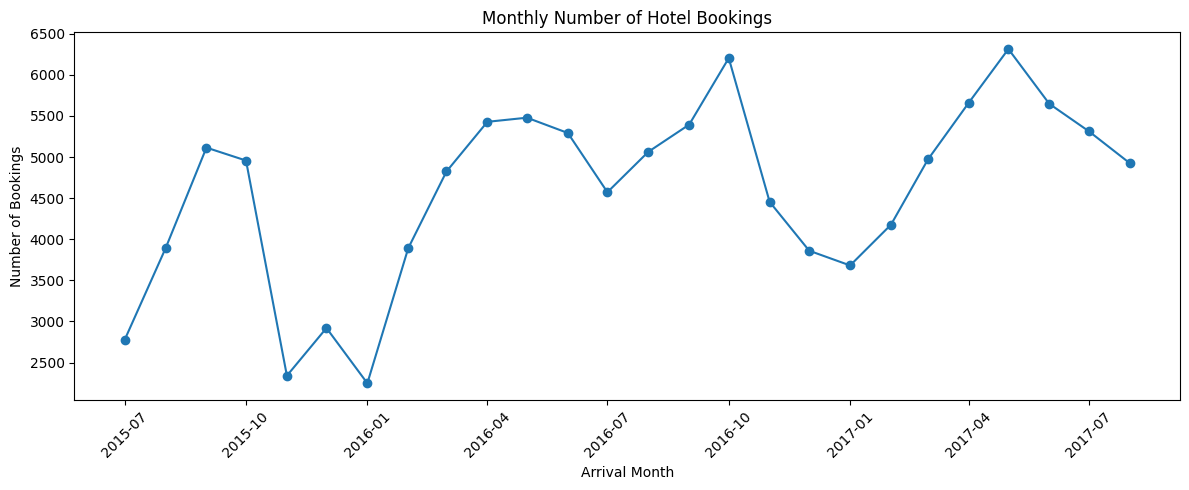

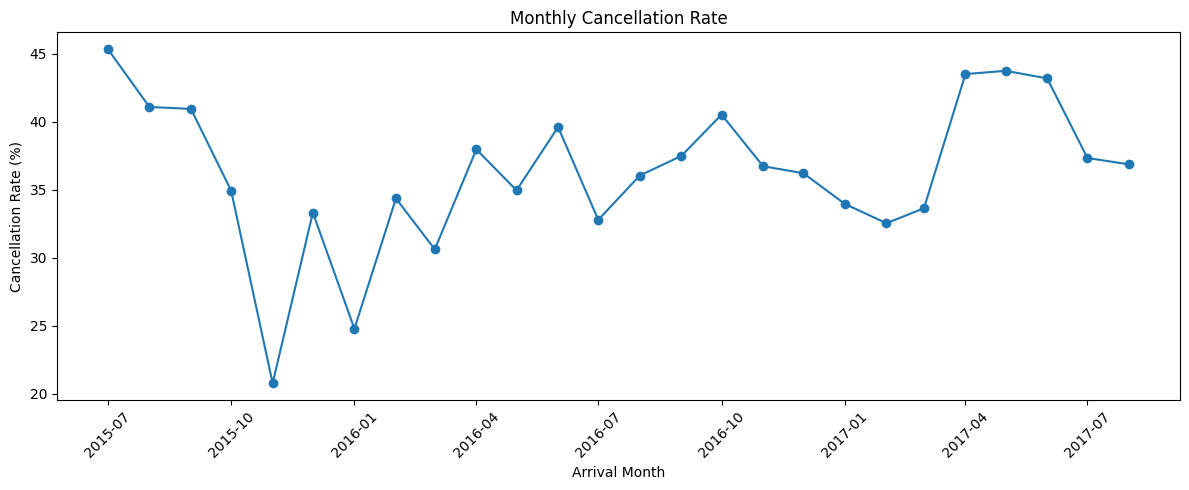

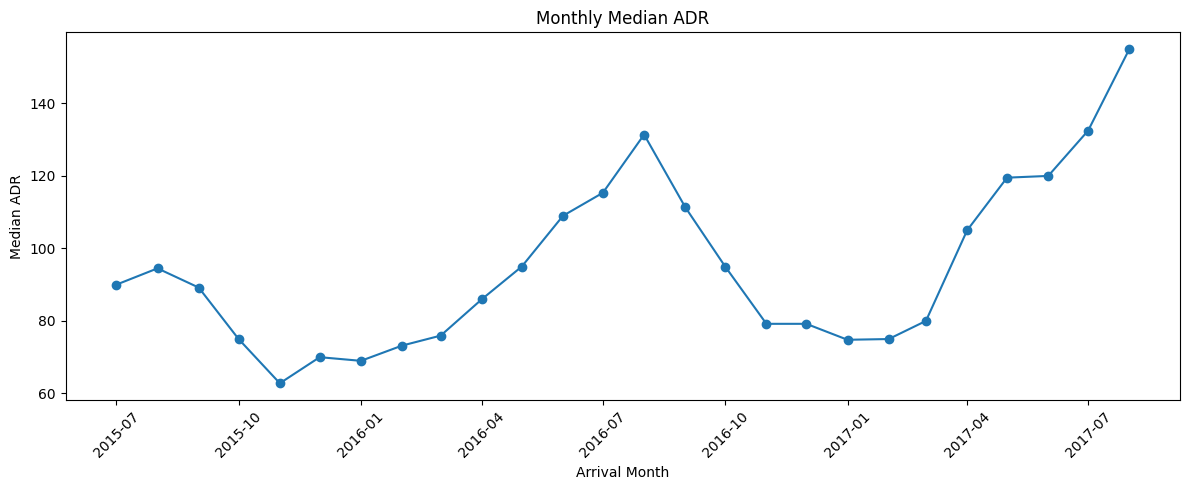

In [32]:
monthly_trends = (
    analysis_data.groupby("arrival_month")
    .agg(
        Bookings=("is_canceled", "size"),
        Cancellation_Rate=("is_canceled", "mean"),
        Median_ADR=("adr", "median"),
    )
    .reset_index()
)
monthly_trends["Cancellation Rate (%)"] = (monthly_trends["Cancellation_Rate"] * 100).round(2)
monthly_trends["Median ADR"] = monthly_trends["Median_ADR"].round(2)

display(monthly_trends[["arrival_month", "Bookings", "Cancellation Rate (%)", "Median ADR"]])

plt.figure(figsize=(12, 5))
plt.plot(monthly_trends["arrival_month"], monthly_trends["Bookings"], marker="o")
plt.title("Monthly Number of Hotel Bookings")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_trends["arrival_month"], monthly_trends["Cancellation Rate (%)"], marker="o")
plt.title("Monthly Cancellation Rate")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_trends["arrival_month"], monthly_trends["Median ADR"], marker="o")
plt.title("Monthly Median ADR")
plt.xlabel("Arrival Month")
plt.ylabel("Median ADR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
season_mapping = {
    "December": "Winter",
    "January": "Winter",
    "February": "Winter",
    "March": "Spring",
    "April": "Spring",
    "May": "Spring",
    "June": "Summer",
    "July": "Summer",
    "August": "Summer",
    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn",
}

analysis_data["arrival_season"] = analysis_data["arrival_date_month"].map(season_mapping)

seasonal_summary = (
    analysis_data.groupby("arrival_season")
    .agg(
        Bookings=("is_canceled", "size"),
        Cancellation_Rate=("is_canceled", "mean"),
        Median_ADR=("adr", "median"),
    )
    .reset_index()
)
seasonal_summary["Cancellation Rate (%)"] = (seasonal_summary["Cancellation_Rate"] * 100).round(2)
seasonal_summary["Median ADR"] = seasonal_summary["Median_ADR"].round(2)

display(seasonal_summary[["arrival_season", "Bookings", "Cancellation Rate (%)", "Median ADR"]])

,arrival_season,Bookings,Cancellation Rate (%),Median ADR
0,Autumn,28462,36.84,88.0
1,Spring,32674,37.80,93.6
2,Summer,37477,38.73,120.0
3,Winter,20777,33.08,74.8


### Time Interpretation

Booking volume, cancellation behavior, and ADR vary materially across months and seasons. Calendar season provides useful external context about time, but the dataset itself does not include exogenous drivers such as weather, public holidays, tourism flows, or major events. Therefore, temporal associations can be described, but their exact causes cannot be established from this dataset alone.

## 9.2 Feature Engineering

In [34]:
engineered_data = analysis_data.copy()
engineered_data["children"] = engineered_data["children"].fillna(
    engineered_data["children"].median()
)

engineered_data["total_nights"] = (
    engineered_data["stays_in_weekend_nights"]
    + engineered_data["stays_in_week_nights"]
)
engineered_data["total_guests"] = (
    engineered_data["adults"]
    + engineered_data["children"]
    + engineered_data["babies"]
)
engineered_data["is_family"] = (
    (engineered_data["children"] > 0)
    | (engineered_data["babies"] > 0)
).astype(int)
engineered_data["room_changed"] = (
    engineered_data["reserved_room_type"]
    != engineered_data["assigned_room_type"]
).astype(int)
engineered_data["estimated_booking_value"] = np.where(
    (engineered_data["adr"] >= 0)
    & (engineered_data["total_nights"] > 0),
    engineered_data["adr"] * engineered_data["total_nights"],
    np.nan,
)

new_feature_columns = [
    "total_nights",
    "total_guests",
    "is_family",
    "room_changed",
    "estimated_booking_value",
    "arrival_season",
]

display(engineered_data[new_feature_columns].head())

display(pd.DataFrame({
    "Feature": new_feature_columns,
    "Missing Values": [engineered_data[column].isna().sum() for column in new_feature_columns],
    "Unique Values": [engineered_data[column].nunique(dropna=False) for column in new_feature_columns],
}))

,total_nights,total_guests,is_family,room_changed,estimated_booking_value,arrival_season
0,0,2.0,0,0,NaN,Summer
1,0,2.0,0,0,NaN,Summer
2,1,1.0,0,1,75.0,Summer
3,1,1.0,0,0,75.0,Summer
4,2,2.0,0,0,196.0,Summer


,Feature,Missing Values,Unique Values
0,total_nights,0,45
1,total_guests,0,15
2,is_family,0,2
3,room_changed,0,2
4,estimated_booking_value,716,14553
5,arrival_season,0,4


### Feature-Engineering Interpretation

- `total_nights` provides a single measure of stay duration.
- `total_guests` provides complete party size.
- `is_family` supports direct family/non-family comparison.
- `room_changed` identifies reservations where assigned room type differs from reserved room type.
- `estimated_booking_value` approximates stay value using ADR × total nights. Negative ADR and zero-night records are intentionally left missing rather than assigned an artificial value.
- `arrival_season` provides a broader calendar context than individual months.

## 9.3 Hypothesis Testing

### Research Question

Is hotel type statistically associated with booking cancellation?

- **H0:** hotel type and cancellation status are independent.
- **H1:** hotel type and cancellation status are associated.
- Significance level: α = 0.05.

In [35]:
hotel_cancellation_table = pd.crosstab(hotel_data["hotel"], hotel_data["is_canceled"])
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(
    hotel_cancellation_table
)

sample_size = hotel_cancellation_table.to_numpy().sum()
minimum_dimension = min(hotel_cancellation_table.shape) - 1
cramers_v = np.sqrt(chi2_statistic / (sample_size * minimum_dimension))
alpha = 0.05

hotel_cancellation_rates = (
    hotel_data.groupby("hotel")["is_canceled"].mean().mul(100).round(2)
)

print("Observed frequency table:")
display(hotel_cancellation_table)

print("Cancellation rate by hotel (%):")
display(hotel_cancellation_rates.rename("Cancellation Rate (%)").to_frame())

hypothesis_results = pd.DataFrame({
    "Metric": [
        "Chi-Square Statistic",
        "Degrees of Freedom",
        "P-value",
        "Cramer's V",
        "Significance Level",
    ],
    "Value": [
        round(chi2_statistic, 4),
        degrees_of_freedom,
        "< 0.000001" if p_value < 0.000001 else f"{p_value:.6f}",
        round(cramers_v, 4),
        alpha,
    ],
})
display(hypothesis_results)

if p_value < alpha:
    print("Decision: Reject H0. Hotel type and cancellation status are statistically associated.")
else:
    print("Decision: Fail to reject H0. There is insufficient evidence of an association.")

Observed frequency table:


is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


Cancellation rate by hotel (%):


,Cancellation Rate (%)
hotel,
City Hotel,41.73
Resort Hotel,27.76


,Metric,Value
0,Chi-Square Statistic,2224.9249
1,Degrees of Freedom,1
2,P-value,< 0.000001
3,Cramer's V,0.1365
4,Significance Level,0.05


Decision: Reject H0. Hotel type and cancellation status are statistically associated.


### Hypothesis-Test Interpretation

The association between hotel type and cancellation status is statistically significant. However, Cramér's V should be considered together with the very large sample size: a large dataset can make relatively modest effects highly significant. The test establishes association, not causation.

## 9.4 Suggestions for Further Research

1. **Cancellation prediction:** build a model using features that are known at booking time, while excluding leakage variables such as `reservation_status` and `reservation_status_date`.
2. **Time-aware validation:** use chronological train/test splits so future information is not used to predict earlier bookings.
3. **External temporal data:** join weather, public holidays, tourism statistics, major events, or economic indicators to explain monthly and seasonal patterns.
4. **Customer segmentation:** cluster customers using lead time, stay duration, party size, ADR, special requests, and booking channel.
5. **Revenue analysis:** study ADR and `estimated_booking_value` across seasons, customer types, and booking channels.
6. **Channel behavior:** compare cancellation risk between direct, online travel agency, offline agency, corporate, and group bookings.
7. **Room-assignment changes:** investigate whether `room_changed` is associated with booking changes, special requests, cancellation status, or price.
8. **Missingness research:** model the probability of missing `agent`, `company`, or `country` to better understand whether the missing-data mechanism is operationally informative.

# Final Conclusion

This EDA demonstrates that the hotel booking dataset contains rich structure but also important caveats. Cancellation behavior is strongly associated with booking lead time and several categorical booking characteristics, while numerical relationships are generally weak to moderate. The dataset includes structured missingness, duplicate-looking records without a unique booking ID, suspicious operational values, strong skewness, and time dependence.

The key lesson is that the data should be interpreted as the output of a real measurement and business process rather than as unquestionable truth. Good analysis requires understanding what was recorded, what is missing, what may be biased, and which variables could introduce leakage or misleading conclusions.